# Extension of the Credal-Set Diversity Vector with Discourse Coherence

Previous 3D vector:

$$\mathbf{v}_p = (D_{\text{sem}}, D_{\text{lex}}, D_{\text{syn}})$$

Extension **$D_{\text{disc}}$: Discourse Diversity** based on the Entity-Grid model (Barzilay & Lapata, 2008).

$$\mathbf{v}_p^{\text{ext}} = (D_{\text{sem}}, D_{\text{lex}}, D_{\text{syn}}, \underbrace{D_{\text{disc}}}_{\text{new}})$$

### Data
Generated data from `data_generation/generations/` switchable via `DOMAIN`:
- **`storytelling_n200`**: WritingPrompts (Fan et al., 2018) test split, 200 prompts x 4 LLMs x 5 samples + >=5 human reference stories/prompt
- **`translation_ref3`**: Par3 (Karpinska et al., 2022) pooled German/Russian/Chinese source books, 200 paragraphs x 4 LLMs x 5 samples + >=3 human translations/paragraph
- **`translation_ref4`**: Par3 (Karpinska et al., 2022) pooled German/Russian/Chinese source books, 200 paragraphs x 4 LLMs x 5 samples + >=4 human translations/paragraph


In [51]:
# Load packages
import numpy as np
import pandas as pd
import json, re, os, time, warnings
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import combinations
from collections import Counter
from scipy.spatial.distance import cdist
from scipy.spatial import ConvexHull
from scipy.stats import entropy, mannwhitneyu
from sklearn.decomposition import PCA
from matplotlib.patches import Polygon

warnings.filterwarnings('ignore')
np.random.seed(42)

# Print-oriented plotting defaults: figures are sized close to their intended
# print width (~\linewidth = 160mm = 6.3in) so text isn't tiny once embedded in
# the thesis PDF -- see figsize/fontsize choices per plotting cell below
plt.rcParams.update({'figure.dpi': 150, 'font.size': 11, 'axes.titlesize': 13,
                     'axes.labelsize': 11, 'legend.fontsize': 10,
                     'xtick.labelsize': 10, 'ytick.labelsize': 10})

In [52]:
# Load spaCy
import spacy
nlp = spacy.load('en_core_web_sm')
print('spaCy loaded (en_core_web_sm)')

spaCy loaded (en_core_web_sm)


In [53]:
# Configuration
DOMAIN = 'translation_ref3'  # 'storytelling_n200', 'translation_ref3' or 'translation_ref4'

SOURCES = ['human', 'llama', 'mistral', 'qwen', 'gemma']
N_PROMPTS = 200

DOMAIN_CONFIG = {
    'storytelling_n200': dict(
        data_dir='storytelling_n200',
        gen_file=lambda key: f'writingprompts_{key}_n5.jsonl',
        prompts_file='prompts_sample.jsonl',
        text_field='story',
        human_field='human_stories',
    ),
    'translation_ref3': dict(
        data_dir='translation_ref3',
        gen_file=lambda key: f'par3_{key}_n5.jsonl',
        prompts_file='par3_paragraphs_sample.jsonl',
        text_field='translation',
        human_field='human_translations',
    ),
    'translation_ref4': dict(
        data_dir='translation_ref4',
        gen_file=lambda key: f'par3_{key}_n5.jsonl',
        prompts_file='par3_paragraphs_sample.jsonl',
        text_field='translation',
        human_field='human_translations',
    ),
}

FIG_DIR = Path(f'../../figures/discourse_diversity/{DOMAIN}')
FIG_DIR.mkdir(parents=True, exist_ok=True)

TABLE_DIR = Path(f'../../metrics/01_discourse_diversity/tables/{DOMAIN}')
TABLE_DIR.mkdir(parents=True, exist_ok=True)

SOURCE_COLORS = {'human': '#cb1f73', 'gemma': '#fcc72d', 'llama': '#ea6d3d', 'mistral': '#e03a3c', 'qwen': '#383a6b',}
METRIC_NAMES = ['Sem', 'Lex', 'Syn', 'Disc']


In [54]:
# Helper functions
def jsd(p, q):
    """Jensen-Shannon Divergence"""
    # Add small constant to avoid log(0) issues
    p = np.asarray(p, dtype=float) + 1e-10
    q = np.asarray(q, dtype=float) + 1e-10

    # Normalize to probability distributions
    p /= p.sum(); q /= q.sum()
    m = 0.5 * (p + q)

    # Compute JSD using KL divergence
    return 0.5 * (entropy(p, m) + entropy(q, m))

def cohens_d(a, b):
    '''Cohen's d effect size '''

    # Compute pooled standard deviation
    na, nb = len(a), len(b)
    pooled_std = np.sqrt(((na-1)*a.std()**2 + (nb-1)*b.std()**2) / (na+nb-2))

    # Avoid division by zero
    return (a.mean() - b.mean()) / pooled_std if pooled_std > 0 else 0

def overlap_coefficient(points_a, points_b):
    '''Overlap coefficient based on k-NN distances '''
    
    # Compute pairwise distances
    dists_ab = cdist(points_a, points_b)
    dists_ba = cdist(points_b, points_a)

    # Determine a threshold (0.5 * average minimum distance)
    all_pts = np.vstack([points_a, points_b])
    all_d = cdist(all_pts, all_pts)
    np.fill_diagonal(all_d, np.inf)
    theta = 0.5 * np.mean(all_d.min(axis=1))

    # Compute the fraction of points within theta of the other set
    a_near = np.mean(dists_ab.min(axis=1) < theta)
    b_near = np.mean(dists_ba.min(axis=1) < theta)
    
    return 0.5 * (a_near + b_near)

## Load Data

In [55]:
# Repo root importable regardless of the kernel's working directory
def find_repo_root(start=None):
    start = Path(start or Path.cwd())
    for p in [start, *start.parents]:
        if (p / 'metrics' / 'metrics_lib').is_dir() and (p / 'data_generation' / 'generations').is_dir():
            return p
    raise FileNotFoundError("Could not locate the repo root (expected 'metrics/metrics_lib/' and "
                             "'data_generation/generations/')")

REPO_ROOT = find_repo_root()

# Load data
cfg = DOMAIN_CONFIG[DOMAIN]
DATA_DIR = REPO_ROOT / 'data_generation' / 'generations' / cfg['data_dir']
print(f"DOMAIN = {DOMAIN!r}  ({DATA_DIR})")

# Prompt order + human reference texts, from the shared prompts file (one row per prompt/paragraph)
prompt_ids, human_raw = [], {}
with open(DATA_DIR / cfg['prompts_file']) as f:
    for line in f:
        r = json.loads(line)
        prompt_ids.append(r['prompt_id'])
        human_raw[r['prompt_id']] = r[cfg['human_field']]
prompt_ids = prompt_ids[:N_PROMPTS]
prompt_index = {pid: i for i, pid in enumerate(prompt_ids)}

texts = {s: {i: [] for i in range(N_PROMPTS)} for s in SOURCES}
for pid, i in prompt_index.items():
    val = human_raw[pid]
    texts['human'][i] = list(val.values()) if isinstance(val, dict) else list(val)

# Generated texts per model (4 LLMs x N_PROMPTS x 5 samples); same quality filter as
# data_description/descriptive_analysis_storytelling.ipynb (drop truncated / language-drift texts)
n_dropped = {}
for key in SOURCES:
    if key == 'human':
        continue
    dropped = 0
    with open(DATA_DIR / cfg['gen_file'](key)) as f:
        for line in f:
            r = json.loads(line)
            pid = r['prompt_id']
            if pid not in prompt_index:
                continue
            if r.get('finish_reason') == 'length' or not r.get('language_ok', True):
                dropped += 1
                continue
            texts[key][prompt_index[pid]].append(r[cfg['text_field']])
    n_dropped[key] = dropped

# Drop prompts where any source ends up with < 2 texts (all-diversity metrics below are
# pairwise and need >= 2 texts per group; an empty group also crashes SBERT encoding).
# Keeps every source's per-prompt array dense and equal-length, as assumed throughout
# the rest of the notebook (paired diversity gap, correlation, PCA, credal sets).
bad_prompts = sorted({p for s in SOURCES for p in range(N_PROMPTS) if len(texts[s][p]) < 2})
if bad_prompts:
    dropped_ids = [prompt_ids[p] for p in bad_prompts]
    pd.DataFrame({'prompt_id': dropped_ids}).to_csv(TABLE_DIR / 'dropped_prompts_empty_group.csv', index=False)
    keep = [p for p in range(N_PROMPTS) if p not in bad_prompts]
    texts = {s: {new_i: texts[s][old_i] for new_i, old_i in enumerate(keep)} for s in SOURCES}
    print(f"Dropped {len(bad_prompts)}/{N_PROMPTS} prompts with < 2 texts in >= 1 source "
          f"(saved to {TABLE_DIR / 'dropped_prompts_empty_group.csv'})")
    N_PROMPTS = len(keep)

total = sum(len(texts[s][p]) for s in SOURCES for p in texts[s])
print(f"{total:,} texts loaded across {len(SOURCES)} sources x {N_PROMPTS} prompts")
print()
print(f'{"Source":10s}  {"Prompts":>7}  {"Texts":>6}  {"Dropped":>7}  {"Min/prompt":>10}  {"Groups<2":>8}')
print("-" * 60)
overview_rows = []
for source in SOURCES:
    sizes = [len(texts[source][p]) for p in texts[source]]
    n_undersized = sum(1 for n in sizes if n < 2)
    print(f"{source:10s}  {N_PROMPTS:>7}  {sum(sizes):>6}  {n_dropped.get(source, '-'):>7}  {min(sizes):>10}  {n_undersized:>8}")
    overview_rows.append({
        'source': source, 'prompts': N_PROMPTS, 'texts': sum(sizes),
        'dropped': n_dropped.get(source, 0), 'min_per_prompt': min(sizes),
        'groups_lt2': n_undersized,
    })
print("-" * 60)

pd.DataFrame(overview_rows).to_csv(TABLE_DIR / 'data_loading_overview.csv', index=False)

DOMAIN = 'translation_ref3'  (/Users/theresawinner/Desktop/Uni/Master/Masterarbeit/Masterthesis/data_generation/generations/translation_ref3)
Dropped 21/200 prompts with < 2 texts in >= 1 source (saved to ../../metrics/01_discourse_diversity/tables/translation_ref3/dropped_prompts_empty_group.csv)
4,034 texts loaded across 5 sources x 179 prompts

Source      Prompts   Texts  Dropped  Min/prompt  Groups<2
------------------------------------------------------------
human           179     600        -           3         0
llama           179     889        9           3         0
mistral         179     873       27           2         0
qwen            179     816      166           2         0
gemma           179     856       64           2         0
------------------------------------------------------------


In [56]:
# D_sem, D_lex, D_syn (same formulas as in metrics_lib's)

from itertools import combinations as _combinations
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

_sbert = SentenceTransformer('all-MiniLM-L6-v2')

def _word_tokens(text):
    # Return a list of lowercase word tokens from the input text
    return re.findall(r"\w+", text.lower())

def _jaccard_distance(a, b):
    # Return the Jaccard distance between two sets a and b
    return 1 - len(a & b) / max(len(a | b), 1)

def semantic_diversity(texts_list):
    """D_sem: mean pairwise cosine distance of SBERT embeddings"""

    # Compute SBERT embeddings
    embs = _sbert.encode(list(texts_list), show_progress_bar=False)

    # Compute cosine similarity matrix
    sim = cosine_similarity(embs)

    # Generate all unique pairs of indices for the texts
    pairs = list(_combinations(range(len(texts_list)), 2))

    # Compute mean pairwise cosine distance
    return float(np.mean([1 - sim[i, j] for i, j in pairs]))

def lexical_diversity(texts_list):
    """D_lex: mean pairwise Jaccard distance of word bigrams"""

    # Compute bigrams for each text
    bigrams = [set(zip(t[:-1], t[1:])) for t in (_word_tokens(x) for x in texts_list)]
    pairs = [(i, j) for i, j in _combinations(range(len(texts_list)), 2) if bigrams[i] or bigrams[j]]

    # Compute mean pairwise Jaccard distance
    return float(np.mean([_jaccard_distance(bigrams[i], bigrams[j]) for i, j in pairs]))

def syntactic_diversity(texts_list):
    """D_syn: mean pairwise Jaccard distance of POS-tag trigrams (spaCy)"""

    # Compute POS tags for each text
    tag_seqs = [[tok.pos_ for tok in nlp(t)] for t in texts_list]

    # Compute trigrams for each text (only if there are at least 3 tags)
    trigrams = [set(zip(tags[:-2], tags[1:-1], tags[2:])) if len(tags) >= 3 else set() for tags in tag_seqs]

    # Generate all unique pairs of indices for the texts, filtering out pairs where both trigrams are empty
    pairs = [(i, j) for i, j in _combinations(range(len(texts_list)), 2) if trigrams[i] or trigrams[j]]

    # Compute mean pairwise Jaccard distance
    return float(np.mean([_jaccard_distance(trigrams[i], trigrams[j]) for i, j in pairs]))

print('D_sem / D_lex / D_syn defined (SBERT cosine dist. / bigram Jaccard / POS-trigram Jaccard)')


# Compute baseline_3d (D_sem, D_lex, D_syn) for each source x prompt
t0 = time.time()
baseline_3d = {}
for source in SOURCES:
    sem, lex, syn = [], [], []
    for p in range(N_PROMPTS):
        group = texts[source][p]
        sem.append(semantic_diversity(group))
        lex.append(lexical_diversity(group))
        syn.append(syntactic_diversity(group))
    baseline_3d[source] = np.column_stack([sem, lex, syn])
    print(f'  {source:8s} done ({time.time()-t0:.0f}s)')

print()
print(f"Baseline distances (mean over {N_PROMPTS} prompts):")

baseline_rows = []
for source in SOURCES:
    means = baseline_3d[source].mean(axis=0)
    stds = baseline_3d[source].std(axis=0)
    print(f'  {source:8s}: Sem={means[0]:.3f}, Lex={means[1]:.3f}, Syn={means[2]:.3f}')
    baseline_rows.append({
        'source': source,
        'Sem_mean': means[0], 'Sem_std': stds[0],
        'Lex_mean': means[1], 'Lex_std': stds[1],
        'Syn_mean': means[2], 'Syn_std': stds[2],
    })
pd.DataFrame(baseline_rows).to_csv(TABLE_DIR / 'baseline_3d_summary.csv', index=False)


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 10208.01it/s]


D_sem / D_lex / D_syn defined (SBERT cosine dist. / bigram Jaccard / POS-trigram Jaccard)
  human    done (37s)
  llama    done (84s)
  mistral  done (133s)
  qwen     done (175s)
  gemma    done (220s)

Baseline distances (mean over 179 prompts):
  human   : Sem=0.211, Lex=0.826, Syn=0.598
  llama   : Sem=0.125, Lex=0.710, Syn=0.485
  mistral : Sem=0.112, Lex=0.639, Syn=0.429
  qwen    : Sem=0.108, Lex=0.676, Syn=0.456
  gemma   : Sem=0.086, Lex=0.575, Syn=0.395


# Simplified Entity Grid (binary)

Simple variant of the Entity-Grid model:

- Each entity is either **present (1)** or **absent (0)** per sentence
- **4 transition types**: `{(0,0), (0,1), (1,0), (1,1)}`
- All entities weighted equally
- Regex-based sentence tokenizer

In [57]:
# D_disc simplified: Binary Entity Grid

def sent_tokenize_simple(text):
    """Sentence tokenizer (spaCy sentencizer)"""
    doc = nlp(text)
    sents = [sent.text.strip() for sent in doc.sents]

    return [s.strip() for s in sents if len(s.strip()) > 5]


def extract_entities_spacy(sentence):
    """Named entities via spaCy NER"""
    doc = nlp(sentence)

    # Only consider relevant entity types
    valid_labels = {'PERSON', 'ORG', 'GPE', 'LOC', 'PRODUCT', 'EVENT', 'WORK_OF_ART'}

    # Extract and return unique entities in lowercase
    return set(ent.text.lower() for ent in doc.ents if ent.label_ in valid_labels)



def entity_grid_transitions(text):
    """Compute entity-grid transitions for a text"""
    sents = sent_tokenize_simple(text)

    # If there are fewer than 2 sentences, return empty transitions and entities
    if len(sents) < 2:
        return Counter(), [], []
    
    # Extract entities per sentence
    sent_entities = [extract_entities_spacy(s) for s in sents]
    all_entities = set().union(*sent_entities)

    # If no entities found, return empty transitions
    if not all_entities:
        return Counter(), sent_entities, list(all_entities)
    
    # Count transitions
    transitions = Counter()
    for entity in all_entities:
        presence = [1 if entity in se else 0 for se in sent_entities]

        # Count transitions between consecutive sentences for this entity
        for k in range(len(presence) - 1):
            transitions[(presence[k], presence[k+1])] += 1

    return transitions, sent_entities, list(all_entities)


SIMPLE_TRANS_TYPES = [(0,0), (0,1), (1,0), (1,1)]


def discourse_diversity_simple(texts_list):
    """D_disc (Simplified): mean pairwise JSD of binary profiles"""
    profiles = []

    # Compute entity-grid transitions for each text and convert to a profile
    for t in texts_list:
        trans, _, _ = entity_grid_transitions(t)
        total = sum(trans.values()) or 1
        profiles.append(np.array([trans[tt] / total for tt in SIMPLE_TRANS_TYPES]))

    # Compute mean pairwise JSD of the profiles
    profiles = np.array(profiles)
    pairs = list(combinations(range(len(texts_list)), 2))
    
    return np.mean([jsd(profiles[i], profiles[j]) for i, j in pairs])


print('D_disc Simplified implemented (binary, 4 transitions)')

D_disc Simplified implemented (binary, 4 transitions)


In [58]:
# Example
example_story = texts['human'][98][3].split('Little did they know')[0].strip()
trans_ex, sent_ents_ex, all_ents_ex = entity_grid_transitions(example_story)
sents_ex = sent_tokenize_simple(example_story)
total_ex = sum(trans_ex.values()) or 1

print(f'Example: Prompt 98, Story 3')
print(f'\nStory:\n{example_story}')
print(f'{len(sents_ex)} sentences, {len(all_ents_ex)} entities')
print(f'\nEntities: {all_ents_ex[:10]}' + (' ...' if len(all_ents_ex) > 10 else ''))
print(f'\nTransitions:')
for tt in SIMPLE_TRANS_TYPES:
    pct = trans_ex[tt] / total_ex * 100
    label = f'{tt[0]}→{tt[1]}'
    bar = '█' * int(pct / 2)
    print(f'  {label}: {pct:5.1f}% {bar}')


IndexError: list index out of range

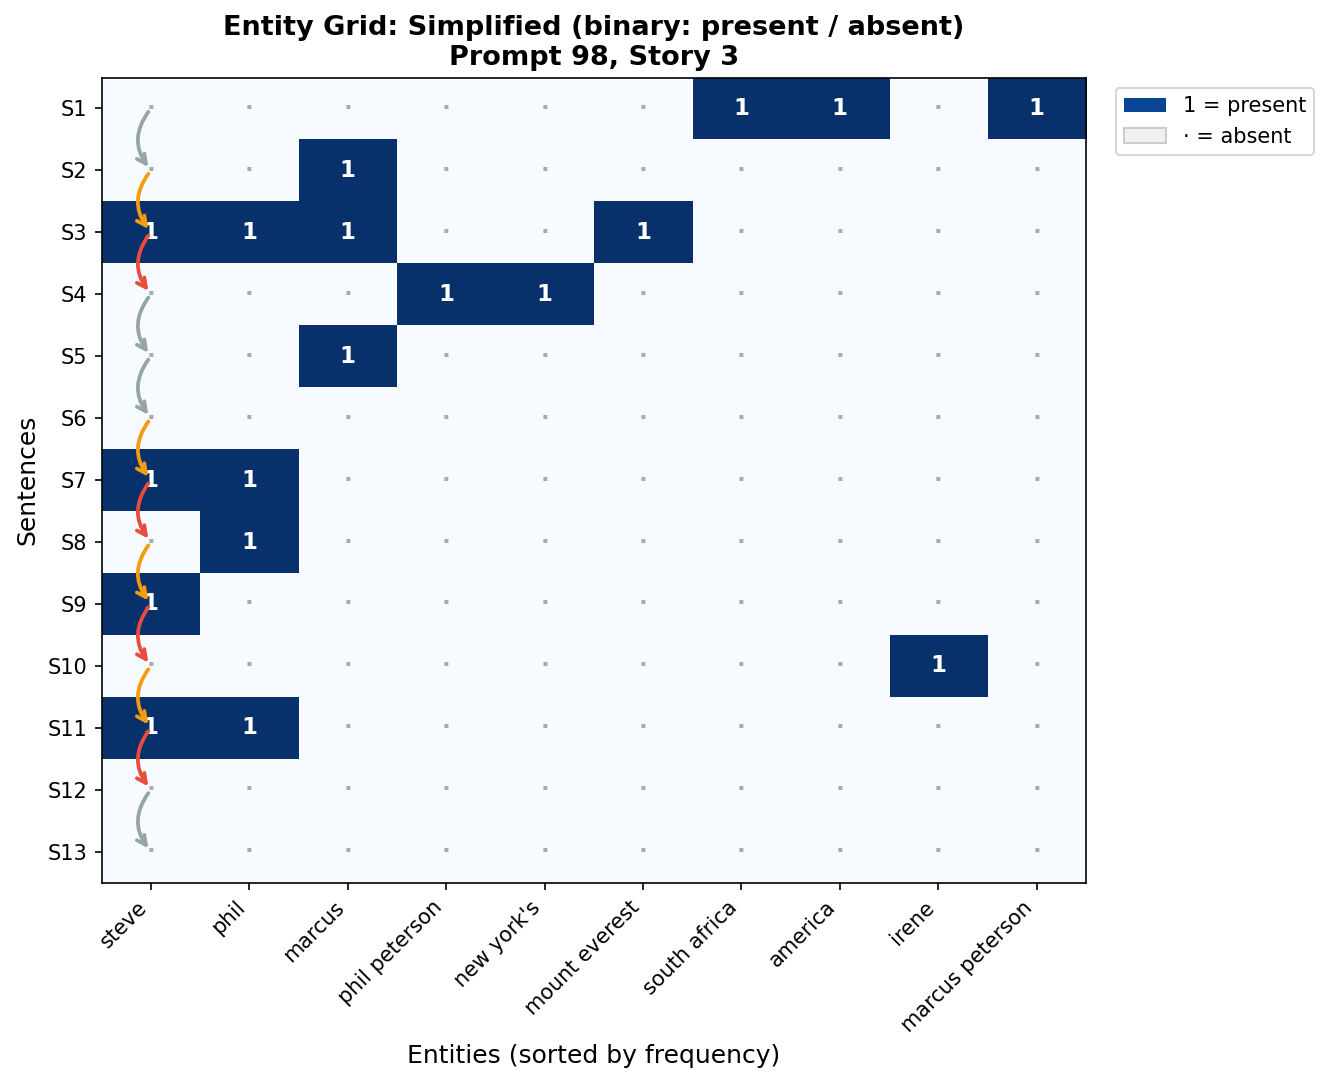


Transition profile for "steve" (1st entity):
  0→0:  89x  ███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  0→1:  13x  ███████████████████████████████████████
  1→0:  16x  ████████████████████████████████████████████████
  1→1:   2x  ██████


In [59]:
# Example entity grid plot

from matplotlib.patches import Patch as _Patch

# Sort entities by frequency
entity_freq_ex = {e: sum(1 for se in sent_ents_ex if e in se) for e in all_ents_ex}
sorted_ents = sorted(all_ents_ex, key=lambda e: -entity_freq_ex[e])

# Limit display to max. 20 entities and 20 sentences
show_ents = sorted_ents[:20]
show_sents = min(len(sents_ex), 20)

# Build binary matrix: rows = sentences, columns = entities
grid_bin = np.zeros((show_sents, len(show_ents)), dtype=int)
for j, ent in enumerate(show_ents):
    for i in range(show_sents):
        grid_bin[i, j] = 1 if ent in sent_ents_ex[i] else 0

fig, ax = plt.subplots(figsize=(max(8, len(show_ents) * 0.9), show_sents * 0.45 + 1.5))
cmap_bin = plt.cm.Blues
ax.imshow(grid_bin, cmap=cmap_bin, aspect='auto', vmin=0, vmax=1)

ax.set_xticks(range(len(show_ents)))
ax.set_xticklabels(show_ents, rotation=45, ha='right', fontsize=10)
ax.set_yticks(range(show_sents))
ax.set_yticklabels([f'S{i+1}' for i in range(show_sents)], fontsize=10)
ax.set_xlabel('Entities (sorted by frequency)', fontsize=12)
ax.set_ylabel('Sentences', fontsize=12)
ax.set_title('Entity Grid: Simplified (binary: present / absent)\n'
             f'Prompt 98, Story 3',
             fontsize=13, fontweight='bold')

# Cell content: 1 / · 
for i in range(show_sents):
    for j in range(len(show_ents)):
        val = grid_bin[i, j]
        label = '1' if val == 1 else '·'
        color = 'white' if val == 1 else '#AAAAAA'
        ax.text(j, i, label, ha='center', va='center',
                fontsize=11, fontweight='bold', color=color)

legend_elements = [
    _Patch(facecolor='#084594', label='1 = present'),
    _Patch(facecolor='#F0F0F0', edgecolor='#CCCCCC', label='· = absent'),
]
ax.legend(handles=legend_elements, loc='upper left',
          bbox_to_anchor=(1.02, 1), fontsize=10)

# Transition annotation: highlight first entity
if len(show_ents) > 0 and show_sents > 1:
    ent0 = show_ents[0]
    presence0 = [grid_bin[i, 0] for i in range(show_sents)]
    for i in range(show_sents - 1):
        pair = (presence0[i], presence0[i + 1])
        colors = {(1, 1): '#27AE60', (1, 0): '#E74C3C',
                  (0, 1): '#F39C12', (0, 0): '#95A5A6'}
        ax.annotate('', xy=(0, i + 1), xytext=(0, i),
                    xycoords=('data', 'data'), textcoords=('data', 'data'),
                    arrowprops=dict(arrowstyle='->', color=colors[pair],
                                   lw=1.8, connectionstyle='arc3,rad=0.4'))

plt.tight_layout()
plt.savefig(FIG_DIR / 'entity_grid_simple_example.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'\nTransition profile for "{show_ents[0] if show_ents else "—"}" (1st entity):')
if show_ents:
    for tt in SIMPLE_TRANS_TYPES:
        lbl = f'{tt[0]}→{tt[1]}'
        n = trans_ex[tt]
        bar = '█' * int(n * 3)
        print(f'  {lbl}: {n:3d}x  {bar}')

In [60]:
# Computation for all prompts

disc_scores_simple = {}
t0 = time.time()

# Compute 4D vector (Sem, Lex, Syn, Disc) for all prompts
for source in SOURCES:
    scores = []
    for p in range(N_PROMPTS):
        scores.append(discourse_diversity_simple(texts[source][p]))
        if (p + 1) % 50 == 0:
            print(f'  {source:8s}: {p+1}/{N_PROMPTS} ({time.time()-t0:.0f}s)')
    disc_scores_simple[source] = np.array(scores)

print(f'\nDone in {time.time()-t0:.0f}s')

# Assemble 4D vector (Sem, Lex, Syn, Disc)
results_4d_simple = {}
for source in SOURCES:
    results_4d_simple[source] = np.column_stack([
        baseline_3d[source], disc_scores_simple[source]
    ])

print(f'\n4D vector (Simplified): (Sem, Lex, Syn, Disc)')
print(f'{"":<10}', end='')

for s in SOURCES: print(f'{s:>14}', end='')
print()
print('-' * 80)

for i, name in enumerate(METRIC_NAMES):
    print(f'{name:<10}', end='')
    for source in SOURCES:
        m = results_4d_simple[source][:, i].mean()
        s = results_4d_simple[source][:, i].std()
        print(f'{m:>8.4f}±{s:<5.3f}', end='')
    print()

summary_rows = []
for source in SOURCES:
    means = results_4d_simple[source].mean(axis=0)
    stds = results_4d_simple[source].std(axis=0)
    row = {'source': source}
    for i, name in enumerate(METRIC_NAMES):
        row[f'{name}_mean'] = means[i]
        row[f'{name}_std'] = stds[i]
    summary_rows.append(row)
pd.DataFrame(summary_rows).to_csv(TABLE_DIR / 'results_4d_simple_summary.csv', index=False)

per_prompt_rows = []
for source in SOURCES:
    for p in range(N_PROMPTS):
        row = {'source': source, 'prompt_idx': p}
        row.update(dict(zip(METRIC_NAMES, results_4d_simple[source][p])))
        per_prompt_rows.append(row)
pd.DataFrame(per_prompt_rows).to_csv(TABLE_DIR / 'results_4d_simple_per_prompt.csv', index=False)

  human   : 50/179 (20s)
  human   : 100/179 (40s)
  human   : 150/179 (65s)
  llama   : 50/179 (105s)
  llama   : 100/179 (132s)
  llama   : 150/179 (161s)
  mistral : 50/179 (206s)
  mistral : 100/179 (232s)
  mistral : 150/179 (262s)
  qwen    : 50/179 (301s)
  qwen    : 100/179 (326s)
  qwen    : 150/179 (353s)
  gemma   : 50/179 (394s)
  gemma   : 100/179 (419s)
  gemma   : 150/179 (447s)

Done in 463s

4D vector (Simplified): (Sem, Lex, Syn, Disc)
                   human         llama       mistral          qwen         gemma
--------------------------------------------------------------------------------
Sem         0.2111±0.139  0.1252±0.066  0.1119±0.064  0.1076±0.059  0.0862±0.049
Lex         0.8261±0.103  0.7097±0.103  0.6390±0.127  0.6756±0.099  0.5754±0.132
Syn         0.5980±0.097  0.4850±0.085  0.4290±0.097  0.4561±0.081  0.3953±0.109
Disc        0.0214±0.046  0.0177±0.037  0.0167±0.039  0.0138±0.034  0.0090±0.028


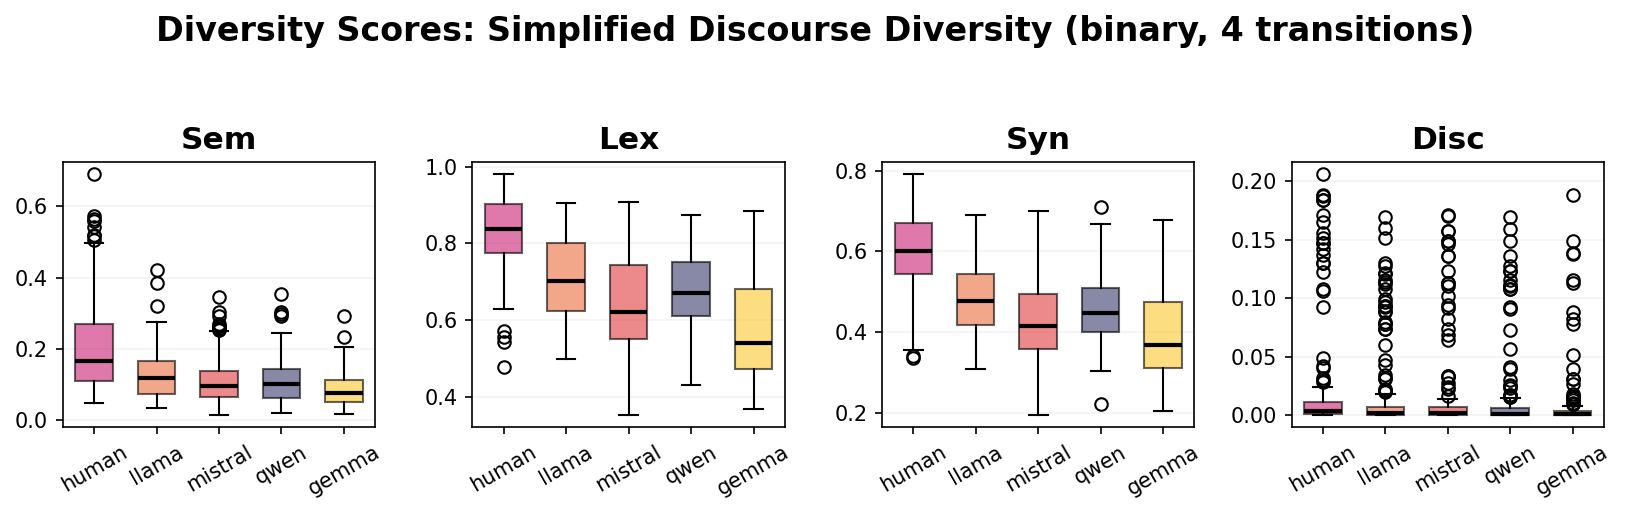

In [61]:
# Boxplots for each metric

fig, axes = plt.subplots(1, 4, figsize=(11, 3.2))
for i, (name, ax) in enumerate(zip(METRIC_NAMES, axes)):
    data = [results_4d_simple[s][:, i] for s in SOURCES]
    bp = ax.boxplot(data, labels=SOURCES, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2), widths=0.6)
    for patch, source in zip(bp['boxes'], SOURCES):
        patch.set_facecolor(SOURCE_COLORS[source])
        patch.set_alpha(0.6)
    ax.set_title(name, fontsize=15, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, alpha=0.15, axis='y')

fig.suptitle('Diversity Scores: Simplified Discourse Diversity (binary, 4 transitions)',
             fontsize=16, fontweight='bold', y=1.06)
plt.tight_layout()
plt.savefig(FIG_DIR / 'boxplots_disc_div_simple.png', dpi=300, bbox_inches='tight')
plt.show()

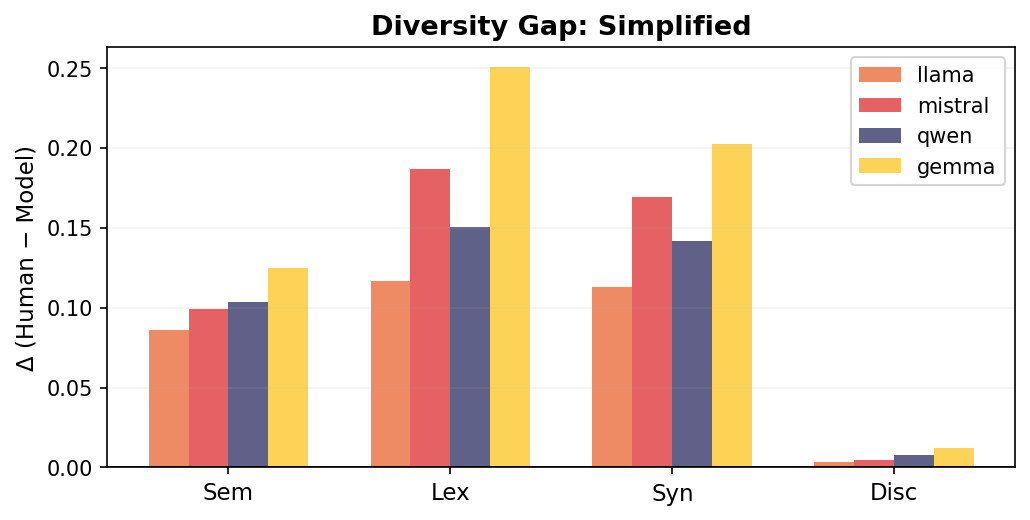

In [62]:
# Diversity Gap

fig, ax = plt.subplots(figsize=(7, 3.6))
x = np.arange(4)
width = 0.18
for j, source in enumerate(SOURCES[1:]):
    deltas = results_4d_simple['human'].mean(axis=0) - results_4d_simple[source].mean(axis=0)
    ax.bar(x + j*width, deltas, width, label=source,
           color=SOURCE_COLORS[source], alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x + 1.5*width)
ax.set_xticklabels(METRIC_NAMES, fontsize=11)
ax.set_ylabel('Δ (Human − Model)', fontsize=11)
ax.set_title('Diversity Gap: Simplified',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.15, axis='y')
plt.tight_layout()
plt.savefig(FIG_DIR / 'diversity_gap_disc_simple.png', dpi=300, bbox_inches='tight')
plt.show()

In [63]:
# Effect Size

print('Effect Size Human vs. Model: D_disc Simplified')
print(f'{"Model":<10} {"Cohen d":>10} {"Strength":>10} {"U-test p":>12}')
print('-' * 46)
h = disc_scores_simple['human']
effect_rows = []
for source in SOURCES[1:]:
    m = disc_scores_simple[source]
    d = cohens_d(h, m)
    _, p_val = mannwhitneyu(h, m, alternative='two-sided')
    strength = 'large' if abs(d) > 0.8 else 'medium' if abs(d) > 0.5 else 'small'
    print(f'{source:<10} {d:>+10.3f} {strength:>10} {p_val:>12.2e}')
    effect_rows.append({'model': source, 'cohens_d': d, 'strength': strength, 'u_test_p': p_val})
pd.DataFrame(effect_rows).to_csv(TABLE_DIR / 'effect_size_disc_simple.csv', index=False)

Effect Size Human vs. Model: D_disc Simplified
Model         Cohen d   Strength     U-test p
----------------------------------------------
llama          +0.087      small     1.40e-03
mistral        +0.108      small     9.51e-04
qwen           +0.187      small     4.14e-05
gemma          +0.324      small     6.48e-10


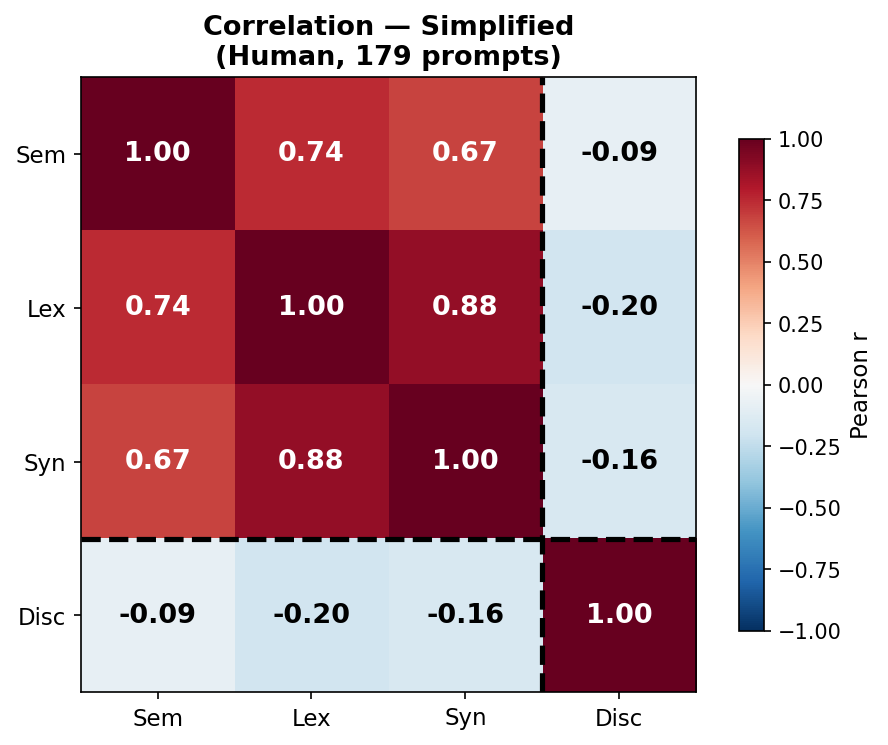

Correlations with D_disc (Simplified):
  Sem–Disc: r = -0.085 (weak)
  Lex–Disc: r = -0.195 (weak)
  Syn–Disc: r = -0.162 (weak)


In [64]:
# Correlation Analysis

corr_simple = np.corrcoef(results_4d_simple['human'].T)

fig, ax = plt.subplots(figsize=(6.5, 5.1))
im = ax.imshow(corr_simple, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_xticklabels(METRIC_NAMES, fontsize=11)
ax.set_yticklabels(METRIC_NAMES, fontsize=11)
for i in range(4):
    for j in range(4):
        c = 'white' if abs(corr_simple[i,j]) > 0.5 else 'black'
        ax.text(j, i, f'{corr_simple[i,j]:.2f}', ha='center', va='center',
                fontsize=13, color=c, fontweight='bold')
ax.axhline(2.5, color='black', linewidth=2.5, linestyle='--')
ax.axvline(2.5, color='black', linewidth=2.5, linestyle='--')
ax.set_title(f'Correlation — Simplified\n(Human, {N_PROMPTS} prompts)',
             fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.8, label='Pearson r')
plt.tight_layout()
plt.savefig(FIG_DIR / 'correlation_matrix_disc_simple.png', dpi=300, bbox_inches='tight')
plt.show()

print('Correlations with D_disc (Simplified):')
for i, name in enumerate(METRIC_NAMES[:3]):
    r = corr_simple[i, 3]
    strength = 'strong' if abs(r) > 0.5 else 'moderate' if abs(r) > 0.3 else 'weak'
    print(f'  {name}–Disc: r = {r:+.3f} ({strength})')

pd.DataFrame(corr_simple, index=METRIC_NAMES, columns=METRIC_NAMES).to_csv(
    TABLE_DIR / 'correlation_matrix_disc_simple.csv')

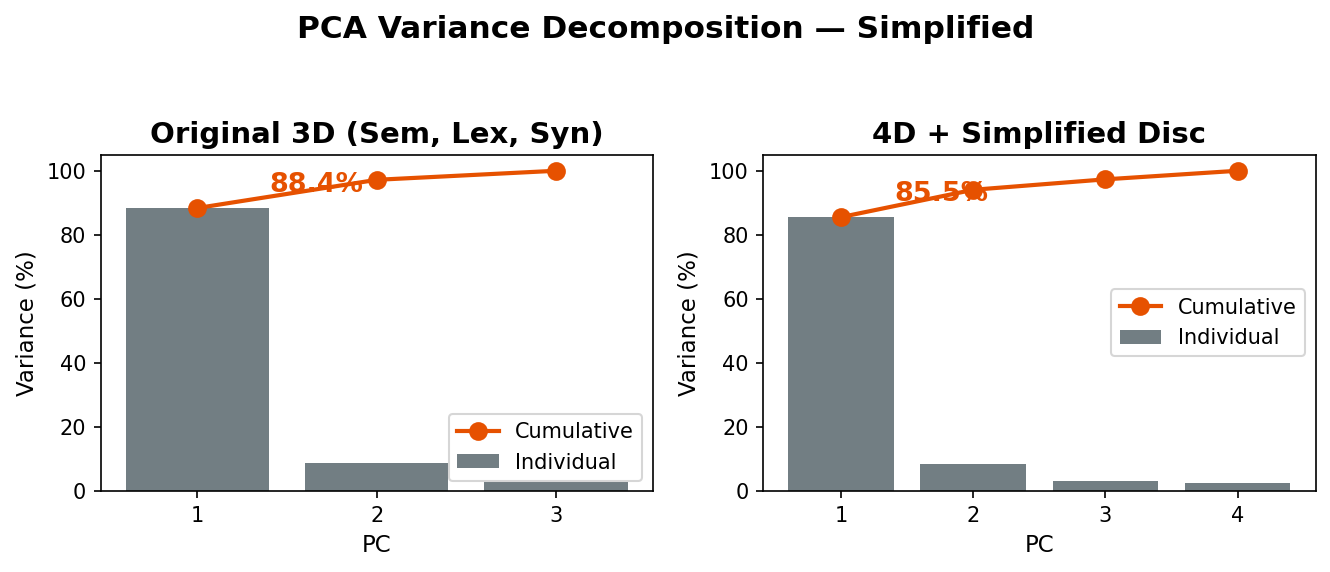

PC1: 3D = 88.4% -> 4D = 85.5% (Drop: 2.8%)


In [65]:
# PCA: 3D vs 4D

all_4d_s = np.vstack([results_4d_simple[s] for s in SOURCES])
all_3d = all_4d_s[:, :3]

pca_3d = PCA().fit(all_3d)
pca_4d_simple = PCA().fit(all_4d_s)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
for ax, pca_obj, title, n_dim in [
    (axes[0], pca_3d,        'Original 3D (Sem, Lex, Syn)', 3),
    (axes[1], pca_4d_simple, '4D + Simplified Disc', 4),
]:
    var = pca_obj.explained_variance_ratio_ * 100
    cum = np.cumsum(var)
    ax.bar(range(1, n_dim+1), var, color='#37474F', alpha=0.7, label='Individual')
    ax.plot(range(1, n_dim+1), cum, 'o-', color='#E65100', linewidth=2,
            markersize=8, label='Cumulative')
    ax.set_xlabel('PC', fontsize=11); ax.set_ylabel('Variance (%)', fontsize=11)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xticks(range(1, n_dim+1))
    ax.legend(fontsize=10)
    ax.annotate(f'{var[0]:.1f}%', xy=(1, var[0]), xytext=(1.4, var[0]+5),
                fontsize=13, fontweight='bold', color='#E65100')
plt.suptitle('PCA Variance Decomposition — Simplified',
             fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig(FIG_DIR / 'pca_variance_disc_simple.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'PC1: 3D = {pca_3d.explained_variance_ratio_[0]:.1%} -> '
      f'4D = {pca_4d_simple.explained_variance_ratio_[0]:.1%} '
      f'(Drop: {pca_3d.explained_variance_ratio_[0] - pca_4d_simple.explained_variance_ratio_[0]:.1%})')

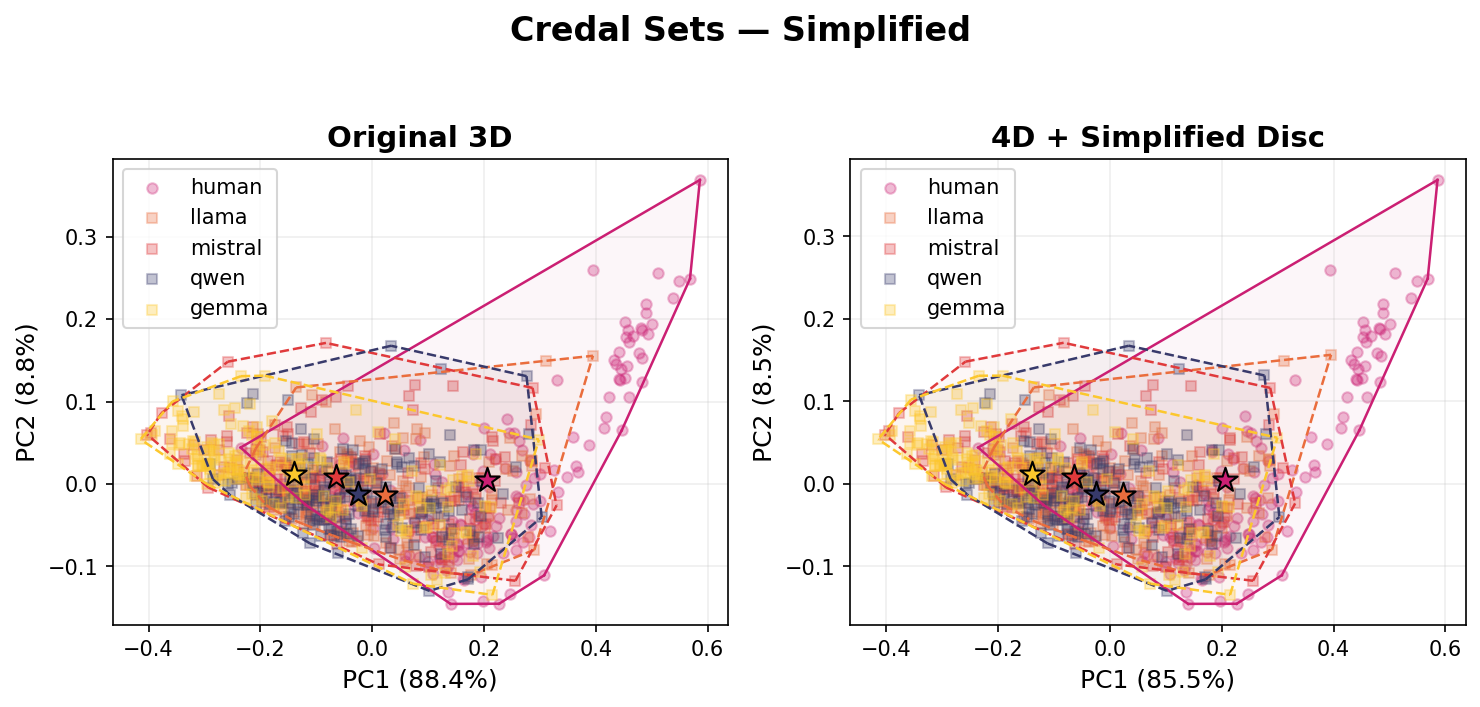

In [66]:
# Credal Sets: 3D vs 4D

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, data_dict, title in [
    (axes[0], {s: results_4d_simple[s][:, :3] for s in SOURCES}, 'Original 3D'),
    (axes[1], results_4d_simple, '4D + Simplified Disc'),
]:
    all_data = np.vstack([data_dict[s] for s in SOURCES])
    pca_2d = PCA(n_components=2)
    all_pca = pca_2d.fit_transform(all_data)
    for i, source in enumerate(SOURCES):
        n = len(data_dict[source])
        pts = all_pca[i*n:(i+1)*n]
        marker = 'o' if source == 'human' else 's'
        ax.scatter(pts[:, 0], pts[:, 1], c=SOURCE_COLORS[source], alpha=0.3,
                  s=25, marker=marker, label=source)
        centroid = pts.mean(axis=0)
        ax.scatter(*centroid, c=SOURCE_COLORS[source], s=150, marker='*',
                  edgecolors='black', linewidth=1, zorder=5)
        try:
            hull = ConvexHull(pts)
            for simplex in hull.simplices:
                ls = '-' if source == 'human' else '--'
                ax.plot(pts[simplex, 0], pts[simplex, 1],
                        color=SOURCE_COLORS[source], linewidth=1.2, linestyle=ls)
            poly = Polygon(pts[hull.vertices], alpha=0.04, color=SOURCE_COLORS[source])
            ax.add_patch(poly)
        except Exception:
            pass
    ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})', fontsize=12)
    ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.2)
plt.suptitle('Credal Sets — Simplified',
             fontsize=16, fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig(FIG_DIR / 'credal_sets_disc_simple_4d.png', dpi=300, bbox_inches='tight')
plt.show()

In [67]:
# Overlap-Koeffizienten

print('Overlap Human and Model: Simplified')
print(f'{"Model":<10} {"3D":>8} {"4D":>8} {"Δ":>8}')
print('-' * 38)
overlap_rows = []
for source in SOURCES[1:]:
    h = results_4d_simple['human']
    m = results_4d_simple[source]
    ov_3d = overlap_coefficient(h[:, :3], m[:, :3])
    ov_4d = overlap_coefficient(h, m)
    print(f'{source:<10} {ov_3d:>8.3f} {ov_4d:>8.3f} {ov_4d-ov_3d:>+8.3f}')
    overlap_rows.append({'model': source, 'overlap_3d': ov_3d, 'overlap_4d': ov_4d, 'delta': ov_4d - ov_3d})
pd.DataFrame(overlap_rows).to_csv(TABLE_DIR / 'overlap_disc_simple.csv', index=False)

Overlap Human and Model: Simplified
Model            3D       4D        Δ
--------------------------------------
llama         0.050    0.059   +0.008
mistral       0.045    0.039   -0.006
qwen          0.025    0.031   +0.006
gemma         0.022    0.022   +0.000


  human   : done (76s)
  llama   : done (175s)
  mistral : done (277s)
  qwen    : done (365s)
  gemma   : done (460s)


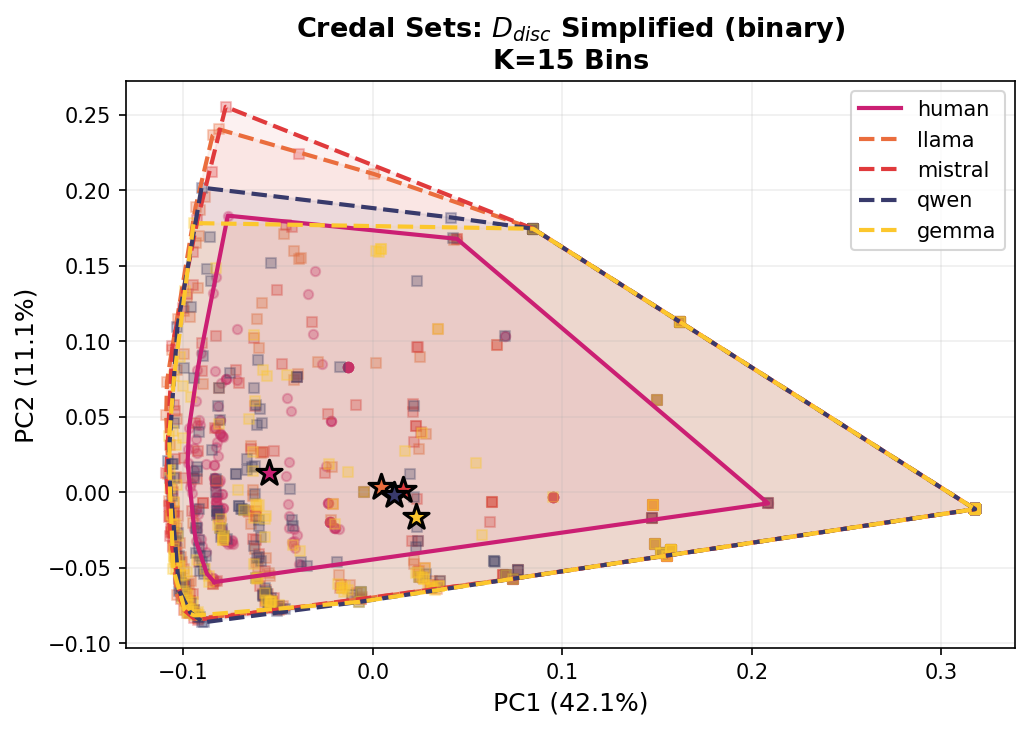

In [68]:
# Credal Sets: D_disc Simplified

K_BINS = 15
ALPHA_SMOOTH = 1.0
BIN_EDGES = np.linspace(0, 1, K_BINS + 1)

def pairwise_jsd_profiles_simple(texts_list):
    """Compute pairwise JSD of binary entity-grid profiles for a list of texts"""
    profiles = []

    # Compute entity-grid transitions for each text and convert to a profile
    for t in texts_list:
        trans, _, _ = entity_grid_transitions(t)
        total = sum(trans.values()) or 1
        profiles.append(np.array([trans[tt] / total for tt in SIMPLE_TRANS_TYPES]))

    # Compute pairwise JSD for all unique pairs of profiles
    pairs = list(combinations(range(len(texts_list)), 2))
    return np.array([jsd(profiles[i], profiles[j]) for i, j in pairs])

raw_dists_simple = {}
t0 = time.time()

# Compute pairwise JSD profiles for all prompts and sources
for source in SOURCES:
    raw_dists_simple[source] = [
        pairwise_jsd_profiles_simple(texts[source][p]) for p in range(N_PROMPTS)
    ]
    print(f'  {source:8s}: done ({time.time()-t0:.0f}s)')

# Transform raw distances to simplex points
all_raw_s = np.concatenate([np.concatenate(raw_dists_simple[s]) for s in SOURCES])
sorted_ref_s = np.sort(all_raw_s)

def rank_transform_s(values):
    """Rank-transform distances to [0, 1] based on reference distribution"""
    return np.searchsorted(sorted_ref_s, values, side='right') / len(sorted_ref_s)

def dist_to_simplex_s(distances):
    """Convert raw distances to a smoothed histogram (simplex point)"""
    # Rank-transform distances to [0, 1]
    ranked = rank_transform_s(distances)

    # Create histogram with smoothing
    counts, _ = np.histogram(ranked, bins=BIN_EDGES)

    # Add smoothing and normalize to get a point on the simplex
    smoothed = counts + ALPHA_SMOOTH
    return smoothed / smoothed.sum()

# Convert all raw distances to simplex points
simplex_simple = {
    s: np.array([dist_to_simplex_s(raw_dists_simple[s][p]) for p in range(N_PROMPTS)])
    for s in SOURCES
}

# Plot
all_sp = np.vstack([simplex_simple[s] for s in SOURCES])
pca_disc_s = PCA(n_components=2).fit(all_sp)
d2d_s = {s: pca_disc_s.transform(simplex_simple[s]) for s in SOURCES}

fig, ax = plt.subplots(figsize=(7, 5))
for source in SOURCES:
    pts = d2d_s[source]
    ls = '-' if source == 'human' else '--'
    marker = 'o' if source == 'human' else 's'
    ax.scatter(pts[:, 0], pts[:, 1], c=SOURCE_COLORS[source],
               alpha=0.3, s=20, marker=marker)
    centroid = pts.mean(axis=0)
    ax.scatter(*centroid, c=SOURCE_COLORS[source], s=160, marker='*',
               edgecolors='black', linewidth=1.5, zorder=6)
    try:
        hull = ConvexHull(pts)
        hull_idx = np.append(hull.vertices, hull.vertices[0])
        ax.fill(pts[hull.vertices, 0], pts[hull.vertices, 1],
                alpha=0.07, color=SOURCE_COLORS[source])
        ax.plot(pts[hull_idx, 0], pts[hull_idx, 1],
                color=SOURCE_COLORS[source], linewidth=2,
                linestyle=ls, label=source)
    except Exception:
        pass
ax.set_xlabel(f'PC1 ({pca_disc_s.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca_disc_s.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax.set_title('Credal Sets: $D_{disc}$ Simplified (binary)\nK=15 Bins',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(FIG_DIR / 'credal_sets_disc_simple.png', dpi=300, bbox_inches='tight')
plt.show()

# Full Entity Grid (Barzilay & Lapata, 2008)

Extension of the simplified model original Entity-Grid:

| Aspect | Part I (Simplified) | Part II (Full Model) |
|---|---|---|
| Entity-Grid roles | binary: present (1) / absent (0) | **S**(ubject), **O**(bject), **X**(other), **–**(absent) |
| Transition types | 4 ($2^2$) | **16** ($4^2$) bigram + **64** ($4^3$) trigram |
| Role assignment | — | **Dependency Parsing** (spaCy) |
| Entity weighting | all equal | **Salience**: $w_e = \log(1 + \text{freq}(e))$ |
| Entity filter | none | $\text{freq}(e) \geq 2$* |

*see later Section for detailed analysis of frequency filter

### Grammatical Roles

| Role | Abbreviation | Dependency Labels (spaCy) |
|---|---|---|
| Subject | **S** | `nsubj`, `nsubjpass`, `csubj` |
| Object | **O** | `dobj`, `iobj`, `pobj`, `attr`, `oprd` |
| Other | **X** | all other grammatical relations |
| Absent | **–** | entity does not appear in the sentence |

$D_{\text{disc}}^{\text{full}} = (1 - \alpha) \cdot \text{JSD}_{\text{bigram}} + \alpha \cdot \text{JSD}_{\text{trigram}}, \quad \alpha = 0.3$

In [69]:
# D_disc: Complete Entity-Grid Model

ROLES = ['S', 'O', 'X', '-']
ROLE_S, ROLE_O, ROLE_X, ROLE_ABSENT = 'S', 'O', 'X', '-'
BIGRAM_TRANSITIONS = [(r1, r2) for r1 in ROLES for r2 in ROLES]  # 16
TRIGRAM_TRANSITIONS = [(r1, r2, r3) for r1 in ROLES for r2 in ROLES for r3 in ROLES]  # 64
N_BIGRAM = len(BIGRAM_TRANSITIONS)
N_TRIGRAM = len(TRIGRAM_TRANSITIONS)
MIN_ENTITY_FREQ = 2

# Improved Sentence Tokenizer
def sent_tokenize_full(text):
    """spaCy sentencizer"""
    doc = nlp(text)
    sents = [sent.text.strip() for sent in doc.sents]
    
    return [s for s in sents if len(s.strip()) > 5]


# Grammatical Roles
_SUBJ_DEPS = {'nsubj', 'nsubjpass', 'csubj', 'csubjpass'}
_OBJ_DEPS = {'dobj', 'iobj', 'pobj', 'attr', 'oprd', 'dative'}
_VALID_NER = {'PERSON', 'ORG', 'GPE', 'LOC', 'PRODUCT', 'EVENT',
              'WORK_OF_ART', 'FAC', 'NORP'}


# Determine role for a token by walking up the dependency chain to the
# governing subject/object (so coordinated/appositive entities, e.g. "Phil
# and Steve" in "...to his sons, Phil and Steve", resolve to the same role)
def _get_role_for_token(token):
    node = token
    while True:
        if node.dep_ in _SUBJ_DEPS:
            return ROLE_S
        if node.dep_ in _OBJ_DEPS:
            return ROLE_O
        if node.head == node:
            return ROLE_X
        node = node.head


def extract_entity_roles_spacy(sent_doc):
    """Entities + grammatical roles via spaCy. Priority: S > O > X"""
    entity_roles = {}
    role_priority = {ROLE_S: 3, ROLE_O: 2, ROLE_X: 1}

    # Extract entities and determine their roles based on dependency parsing
    for ent in sent_doc.ents:
        if ent.label_ not in _VALID_NER:
            continue
        
        # Normalize entity name
        name = ent.text.lower().strip()
        if len(name) < 2:
            continue

        role = ROLE_X

        # Check all tokens in the entity span to determine the highest-priority role
        for token in ent:
            token_role = _get_role_for_token(token)
            if role_priority.get(token_role, 0) > role_priority.get(role, 0):
                role = token_role
    
        # Update entity role if it's the first occurrence or if the new role has higher priority
        if name not in entity_roles or \
           role_priority[role] > role_priority[entity_roles[name]]:
            entity_roles[name] = role

    return entity_roles



def build_entity_grid_full(text):
    """Full entity grid with S/O/X/– roles and frequency filtering"""
    sents = sent_tokenize_full(text)

    # If fewer than 2 sentences, return empty grid and frequencies
    if len(sents) < 2:
        return {}, sents, {}
    
    sent_entity_roles = []

    # Extract entities and their roles for all sentences in a single batch
    docs = list(nlp.pipe(sents, batch_size=50))
    for doc in docs:
        sent_entity_roles.append(extract_entity_roles_spacy(doc))
    
    # Collect all unique entities across sentences
    all_entities = set()
    for roles in sent_entity_roles:
        all_entities.update(roles.keys())

    if not all_entities:
        return {}, sents, {}
    
    # Build the entity grid and count frequencies
    grid = {}
    entity_freq = {}
    for entity in all_entities:
        roles_seq = []
        freq = 0

        # For each sentence, determine the role of the entity (or absence)
        for sent_roles in sent_entity_roles:
            if entity in sent_roles:
                roles_seq.append(sent_roles[entity])
                freq += 1

            else:
                roles_seq.append(ROLE_ABSENT)

        grid[entity] = roles_seq
        entity_freq[entity] = freq

    return grid, sents, entity_freq


def compute_transition_profile_full(text, use_trigrams=True):
    """Weighted bigram+trigram profile based on entity grid with frequency filtering"""
    grid, sents, entity_freq = build_entity_grid_full(text)

    # If no valid grid or fewer than 2 sentences, return uniform profiles and empty grid/frequencies
    if not grid or len(sents) < 2:
        return (np.ones(N_BIGRAM) / N_BIGRAM,
                np.ones(N_TRIGRAM) / N_TRIGRAM if use_trigrams else None, grid, sents, entity_freq)
    
    # Count bigram and trigram transitions, weighted by log(1 + frequency)
    bigram_counts = Counter()
    trigram_counts = Counter()
    for entity, roles_seq in grid.items():

        # Filter out low-frequency entities
        if entity_freq[entity] < MIN_ENTITY_FREQ:
            continue
        weight = np.log(1 + entity_freq[entity])

        # Bigram transitions
        for k in range(len(roles_seq) - 1):
            bigram_counts[(roles_seq[k], roles_seq[k+1])] += weight

        # Trigram transitions
        if use_trigrams and len(roles_seq) >= 3:
            for k in range(len(roles_seq) - 2):
                trigram_counts[(roles_seq[k], roles_seq[k+1], roles_seq[k+2])] += weight

    # Normalize to get profiles
    bigram_total = sum(bigram_counts.values()) or 1
    bigram_profile = np.array([bigram_counts[t] / bigram_total for t in BIGRAM_TRANSITIONS])
    trigram_profile = None

    if use_trigrams:
        trigram_total = sum(trigram_counts.values()) or 1
        trigram_profile = np.array([trigram_counts[t] / trigram_total for t in TRIGRAM_TRANSITIONS])

    return bigram_profile, trigram_profile, grid, sents, entity_freq


def discourse_diversity_full(texts_list, use_trigrams=True, alpha_trigram=0.3):
    """Full Model D_disc: (1-α)·JSD_bigram + α·JSD_trigram"""
    profiles_bi, profiles_tri = [], []

    # Compute profiles for all texts
    for t in texts_list:
        bi, tri, _, _, _ = compute_transition_profile_full(t, use_trigrams=use_trigrams)
        profiles_bi.append(bi)

        if tri is not None:
            profiles_tri.append(tri)
    
    # Compute pairwise JSD for bigram profiles
    profiles_bi = np.array(profiles_bi)
    pairs = list(combinations(range(len(texts_list)), 2))
    jsd_bi = np.mean([jsd(profiles_bi[i], profiles_bi[j]) for i, j in pairs])

    # Compute pairwise JSD for trigram profiles if available
    if use_trigrams and profiles_tri:
        profiles_tri = np.array(profiles_tri)
        jsd_tri = np.mean([jsd(profiles_tri[i], profiles_tri[j]) for i, j in pairs])
        return (1 - alpha_trigram) * jsd_bi + alpha_trigram * jsd_tri
    
    return jsd_bi


print(f'  Full Model implemented')
print(f'  Roles: {ROLES}')
print(f'  {N_BIGRAM} bigram + {N_TRIGRAM} trigram transitions')
print(f'  Entity filter: freq ≥ {MIN_ENTITY_FREQ}, weighting: log(1 + freq)')
print('  Dep-Parsing: spaCy')

  Full Model implemented
  Roles: ['S', 'O', 'X', '-']
  16 bigram + 64 trigram transitions
  Entity filter: freq ≥ 2, weighting: log(1 + freq)
  Dep-Parsing: spaCy


Example: Prompt 98, Story 3
13 sentences, 10 entities (3 after freq filter)

Top Entities:
  steve                     freq= 4  w=1.61
  phil                      freq= 4  w=1.61
  marcus                    freq= 3  w=1.39

Bigram transitions (top 8 / 16):
  -→-: 0.438 ███████████████████████████████████
  -→S: 0.142 ███████████
  S→-: 0.112 ████████
  O→-: 0.083 ██████
  -→O: 0.083 ██████
  X→-: 0.058 ████
  S→X: 0.029 ██
  -→X: 0.029 ██

Trigram transitions (top 6 / 64):
  -→-→-: 0.228 ██████████████████
  -→S→-: 0.095 ███████
  -→-→S: 0.095 ███████
  O→-→-: 0.091 ███████
  -→O→-: 0.091 ███████
  X→-→-: 0.064 █████


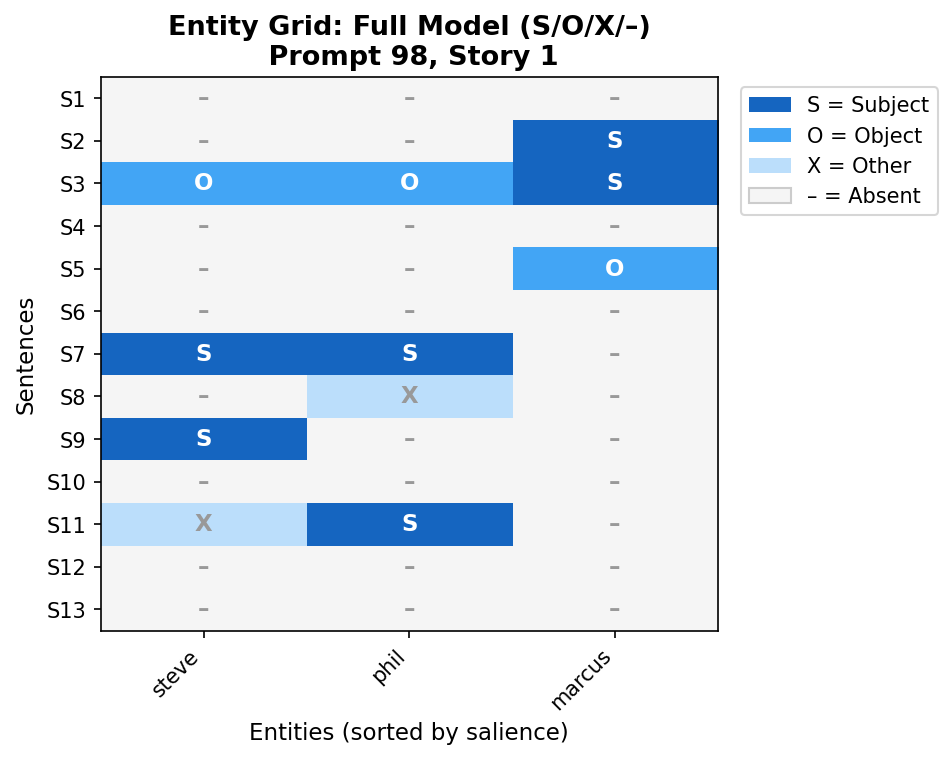

In [70]:
# Example: Entity Grid with S/O/X/– roles

bi_prof, tri_prof, grid_f, sents_f, entity_freq = compute_transition_profile_full(example_story)
filtered = {e: f for e, f in entity_freq.items() if f >= MIN_ENTITY_FREQ}

print(f'Example: Prompt 98, Story 3')
print(f'{len(sents_f)} sentences, {len(grid_f)} entities ({len(filtered)} after freq filter)')
print(f'\nTop Entities:')
for ent, freq in sorted(filtered.items(), key=lambda x: -x[1])[:8]:
    print(f'  {ent:25s} freq={freq:2d}  w={np.log(1+freq):.2f}')

print(f'\nBigram transitions (top 8 / {N_BIGRAM}):')
sorted_bi = sorted(zip(BIGRAM_TRANSITIONS, bi_prof), key=lambda x: -x[1])
for trans, prob in sorted_bi[:8]:
    bar = '█' * int(prob * 80)
    print(f'  {trans[0]}→{trans[1]}: {prob:.3f} {bar}')

if tri_prof is not None:
    print(f'\nTrigram transitions (top 6 / {N_TRIGRAM}):')
    sorted_tri = sorted(zip(TRIGRAM_TRANSITIONS, tri_prof), key=lambda x: -x[1])
    for trans, prob in sorted_tri[:6]:
        bar = '█' * int(prob * 80)
        print(f'  {trans[0]}→{trans[1]}→{trans[2]}: {prob:.3f} {bar}')

# Heatmap
if filtered:
    from matplotlib.colors import ListedColormap
    from matplotlib.patches import Patch
    show_ents = sorted(filtered.keys(), key=lambda e: -entity_freq[e])[:15]
    show_sents = min(len(sents_f), 20)
    role_to_num = {ROLE_S: 3, ROLE_O: 2, ROLE_X: 1, ROLE_ABSENT: 0}
    role_to_label = {ROLE_S: 'S', ROLE_O: 'O', ROLE_X: 'X', ROLE_ABSENT: '–'}
    grid_num = np.zeros((show_sents, len(show_ents)))
    for j, ent in enumerate(show_ents):
        for i in range(show_sents):
            grid_num[i, j] = role_to_num[grid_f[ent][i]]
    cmap = ListedColormap(['#F5F5F5', '#BBDEFB', '#42A5F5', '#1565C0'])
    fig, ax = plt.subplots(figsize=(max(6.5, len(show_ents)*0.75), show_sents*0.4))
    ax.imshow(grid_num, cmap=cmap, aspect='auto', vmin=0, vmax=3)
    ax.set_xticks(range(len(show_ents)))
    ax.set_xticklabels(show_ents, rotation=45, ha='right', fontsize=10)
    ax.set_yticks(range(show_sents))
    ax.set_yticklabels([f'S{i+1}' for i in range(show_sents)], fontsize=10)
    ax.set_xlabel('Entities (sorted by salience)')
    ax.set_ylabel('Sentences')
    ax.set_title('Entity Grid: Full Model (S/O/X/–)\n Prompt 98, Story 1', fontsize=13, fontweight='bold')
    for i in range(show_sents):
        for j in range(len(show_ents)):
            role = grid_f[show_ents[j]][i]
            label = role_to_label[role]
            color = 'white' if role in (ROLE_S, ROLE_O) else '#999999'
            ax.text(j, i, label, ha='center', va='center',
                   fontsize=11, fontweight='bold', color=color)
    legend_elements = [
        Patch(facecolor='#1565C0', label='S = Subject'),
        Patch(facecolor='#42A5F5', label='O = Object'),
        Patch(facecolor='#BBDEFB', label='X = Other'),
        Patch(facecolor='#F5F5F5', edgecolor='#CCCCCC', label='– = Absent'),
    ]
    ax.legend(handles=legend_elements, loc='upper left',
              bbox_to_anchor=(1.02, 1), fontsize=10)
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'entity_grid_full_example.png', dpi=300, bbox_inches='tight')
    plt.show()

In [71]:
# Computation over all prompts

disc_scores_full = {}
t0 = time.time()

# Compute D_disc for all prompts using the full entity-grid model with bigram+trigram profiles
for source in SOURCES:
    scores = []

    for p in range(N_PROMPTS):
        scores.append(discourse_diversity_full(texts[source][p],
                                               use_trigrams=True, alpha_trigram=0.3))
        
        # Progress update every 25 prompts
        if (p + 1) % 25 == 0:
            print(f'  {source:8s}: {p+1}/{N_PROMPTS} ({time.time()-t0:.0f}s)')

    disc_scores_full[source] = np.array(scores)

print(f'\nDone in {time.time()-t0:.0f}s')

# Assemble 4D vector (Sem, Lex, Syn, Disc) for the full model
results_4d_full = {}
for source in SOURCES:
    results_4d_full[source] = np.column_stack([
        baseline_3d[source], disc_scores_full[source]
    ])

print(f'\n4D vector (Full Model): (Sem, Lex, Syn, Disc)')
print(f'{"":<10}', end='')
for s in SOURCES: print(f'{s:>14}', end='')
print()
print('-' * 80)
for i, name in enumerate(METRIC_NAMES):
    print(f'{name:<10}', end='')
    for source in SOURCES:
        m = results_4d_full[source][:, i].mean()
        s = results_4d_full[source][:, i].std()
        print(f'{m:>8.4f}±{s:<5.3f}', end='')
    print()

# Save summary and per-prompt results to CSV files
summary_rows = []
for source in SOURCES:
    means = results_4d_full[source].mean(axis=0)
    stds = results_4d_full[source].std(axis=0)
    row = {'source': source}
    for i, name in enumerate(METRIC_NAMES):
        row[f'{name}_mean'] = means[i]
        row[f'{name}_std'] = stds[i]
    summary_rows.append(row)
pd.DataFrame(summary_rows).to_csv(TABLE_DIR / 'results_4d_full_summary.csv', index=False)

# Save per-prompt results to CSV files
per_prompt_rows = []
for source in SOURCES:
    for p in range(N_PROMPTS):
        row = {'source': source, 'prompt_idx': p}
        row.update(dict(zip(METRIC_NAMES, results_4d_full[source][p])))
        per_prompt_rows.append(row)
pd.DataFrame(per_prompt_rows).to_csv(TABLE_DIR / 'results_4d_full_per_prompt.csv', index=False)

  human   : 25/179 (8s)
  human   : 50/179 (15s)
  human   : 75/179 (21s)
  human   : 100/179 (32s)
  human   : 125/179 (39s)
  human   : 150/179 (51s)
  human   : 175/179 (61s)
  llama   : 25/179 (73s)
  llama   : 50/179 (83s)
  llama   : 75/179 (92s)
  llama   : 100/179 (105s)
  llama   : 125/179 (114s)
  llama   : 150/179 (128s)
  llama   : 175/179 (141s)
  mistral : 25/179 (153s)
  mistral : 50/179 (164s)
  mistral : 75/179 (173s)
  mistral : 100/179 (185s)
  mistral : 125/179 (195s)
  mistral : 150/179 (210s)
  mistral : 175/179 (222s)
  qwen    : 25/179 (232s)
  qwen    : 50/179 (241s)
  qwen    : 75/179 (249s)
  qwen    : 100/179 (260s)
  qwen    : 125/179 (269s)
  qwen    : 150/179 (281s)
  qwen    : 175/179 (292s)
  gemma   : 25/179 (303s)
  gemma   : 50/179 (313s)
  gemma   : 75/179 (321s)
  gemma   : 100/179 (333s)
  gemma   : 125/179 (342s)
  gemma   : 150/179 (355s)
  gemma   : 175/179 (367s)

Done in 368s

4D vector (Full Model): (Sem, Lex, Syn, Disc)
                   h

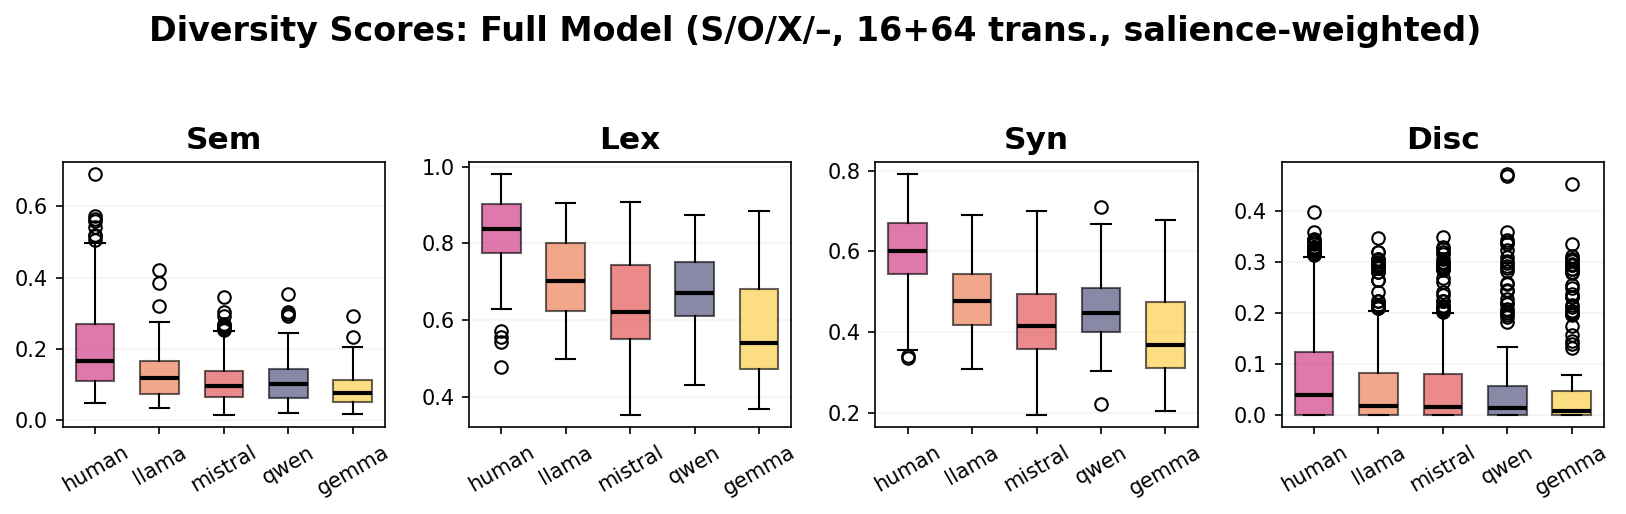

In [72]:
# Boxplot

fig, axes = plt.subplots(1, 4, figsize=(11, 3.2))
for i, (name, ax) in enumerate(zip(METRIC_NAMES, axes)):
    data = [results_4d_full[s][:, i] for s in SOURCES]
    bp = ax.boxplot(data, labels=SOURCES, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2), widths=0.6)
    for patch, source in zip(bp['boxes'], SOURCES):
        patch.set_facecolor(SOURCE_COLORS[source])
        patch.set_alpha(0.6)
    ax.set_title(name, fontsize=15, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, alpha=0.15, axis='y')

fig.suptitle('Diversity Scores: Full Model (S/O/X/–, 16+64 trans., salience-weighted)',
             fontsize=16, fontweight='bold', y=1.06)
plt.tight_layout()
plt.savefig(FIG_DIR / 'diversity_scores_disc_full.png', dpi=300, bbox_inches='tight')
plt.show()

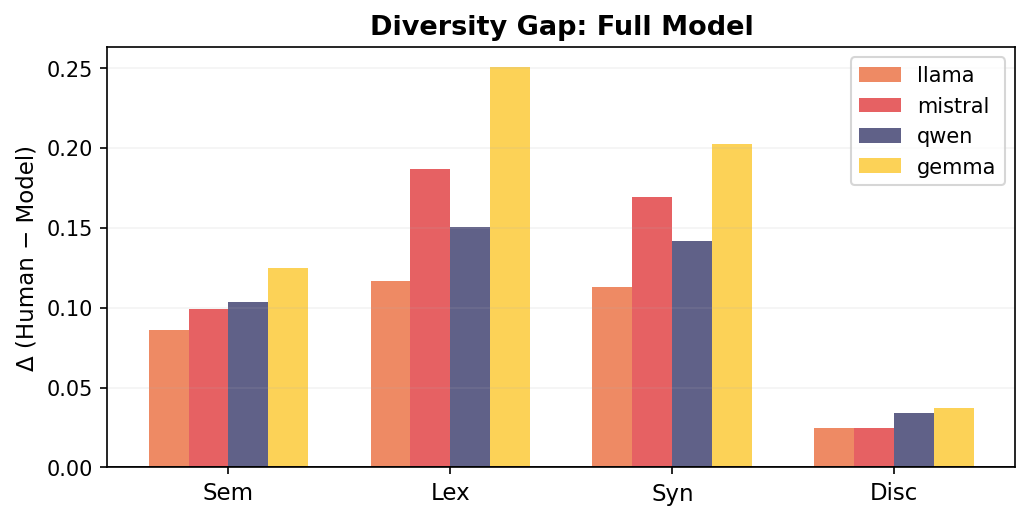

In [73]:
# Diversity Gap

fig, ax = plt.subplots(figsize=(7, 3.6))
x = np.arange(4)
width = 0.18
for j, source in enumerate(SOURCES[1:]):
    deltas = results_4d_full['human'].mean(axis=0) - results_4d_full[source].mean(axis=0)
    ax.bar(x + j*width, deltas, width, label=source,
           color=SOURCE_COLORS[source], alpha=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x + 1.5*width)
ax.set_xticklabels(METRIC_NAMES, fontsize=11)
ax.set_ylabel('Δ (Human − Model)', fontsize=11)
ax.set_title('Diversity Gap: Full Model',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.15, axis='y')
plt.tight_layout()
plt.savefig(FIG_DIR / 'diversity_gap_disc_full.png', dpi=300, bbox_inches='tight')
plt.show()

In [74]:
# Effect Size

print('Effect Size Human vs. Model — D_disc Full Model')
print(f'{"Model":<10} {"Cohen d":>10} {"Strength":>10} {"U-test p":>12}')
print('-' * 46)
h = disc_scores_full['human']
effect_rows = []
for source in SOURCES[1:]:
    m = disc_scores_full[source]
    d = cohens_d(h, m)
    _, p_val = mannwhitneyu(h, m, alternative='two-sided')
    strength = 'large' if abs(d) > 0.8 else 'medium' if abs(d) > 0.5 else 'small'
    print(f'{source:<10} {d:>+10.3f} {strength:>10} {p_val:>12.2e}')
    effect_rows.append({'model': source, 'cohens_d': d, 'strength': strength, 'u_test_p': p_val})
pd.DataFrame(effect_rows).to_csv(TABLE_DIR / 'effect_size_disc_full.csv', index=False)

Effect Size Human vs. Model — D_disc Full Model
Model         Cohen d   Strength     U-test p
----------------------------------------------
llama          +0.227      small     2.58e-02
mistral        +0.228      small     2.05e-02
qwen           +0.311      small     3.35e-03
gemma          +0.345      small     4.34e-04


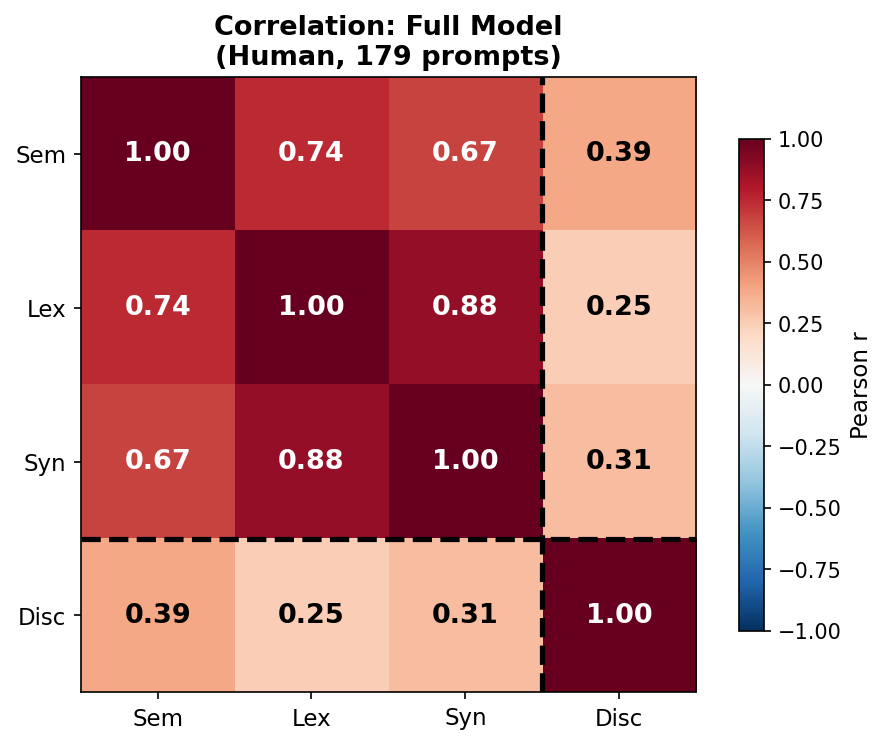

Correlations with D_disc (Full Model):
  Sem–Disc: r = +0.389 (moderate)
  Lex–Disc: r = +0.249 (weak)
  Syn–Disc: r = +0.309 (moderate)


In [75]:
# Correlation Analysis

corr_full = np.corrcoef(results_4d_full['human'].T)

fig, ax = plt.subplots(figsize=(6.5, 5.1))
im = ax.imshow(corr_full, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_xticklabels(METRIC_NAMES, fontsize=11)
ax.set_yticklabels(METRIC_NAMES, fontsize=11)
for i in range(4):
    for j in range(4):
        c = 'white' if abs(corr_full[i,j]) > 0.5 else 'black'
        ax.text(j, i, f'{corr_full[i,j]:.2f}', ha='center', va='center',
                fontsize=13, color=c, fontweight='bold')
ax.axhline(2.5, color='black', linewidth=2.5, linestyle='--')
ax.axvline(2.5, color='black', linewidth=2.5, linestyle='--')
ax.set_title(f'Correlation: Full Model\n(Human, {N_PROMPTS} prompts)',
             fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.8, label='Pearson r')
plt.tight_layout()
plt.savefig(FIG_DIR / 'correlation_matrix_disc_full.png', dpi=300, bbox_inches='tight')   
plt.show()

print('Correlations with D_disc (Full Model):')
for i, name in enumerate(METRIC_NAMES[:3]):
    r = corr_full[i, 3]
    strength = 'strong' if abs(r) > 0.5 else 'moderate' if abs(r) > 0.3 else 'weak'
    print(f'  {name}–Disc: r = {r:+.3f} ({strength})')

pd.DataFrame(corr_full, index=METRIC_NAMES, columns=METRIC_NAMES).to_csv(
    TABLE_DIR / 'correlation_matrix_disc_full.csv')

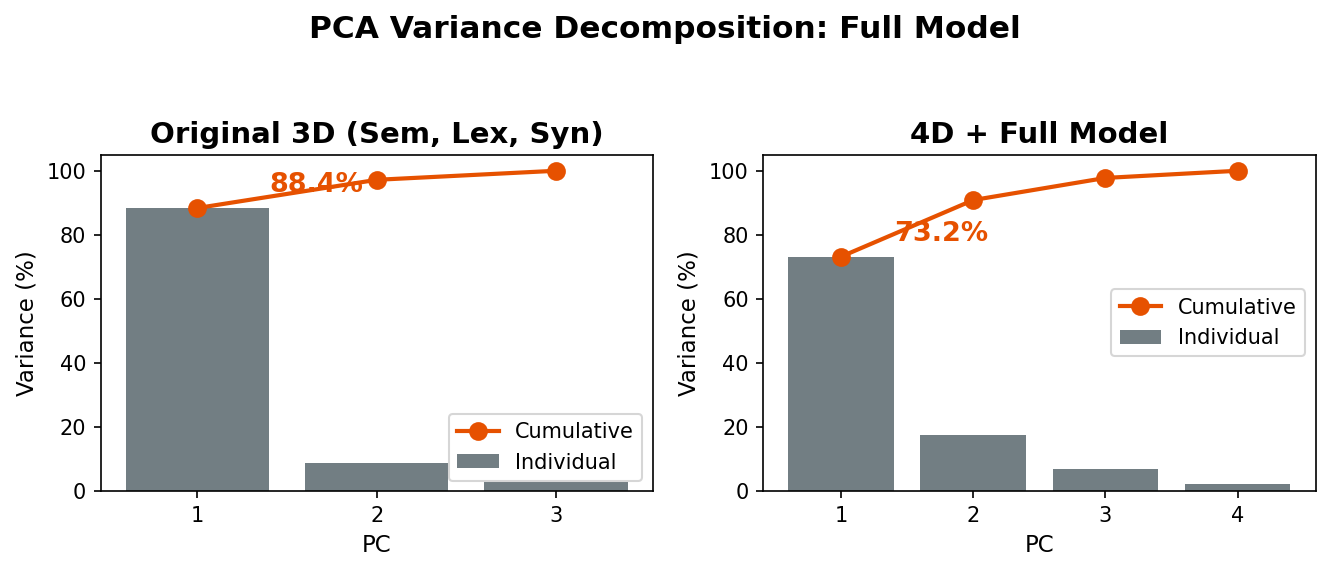

PC1: 3D = 88.4% → 4D = 73.2% (Drop: 15.2%)


In [76]:
# PCA: 3D vs 4D

all_4d_f = np.vstack([results_4d_full[s] for s in SOURCES])
pca_4d_full = PCA().fit(all_4d_f)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
for ax, pca_obj, title, n_dim in [
    (axes[0], pca_3d,      'Original 3D (Sem, Lex, Syn)', 3),
    (axes[1], pca_4d_full, '4D + Full Model', 4),
]:
    var = pca_obj.explained_variance_ratio_ * 100
    cum = np.cumsum(var)
    ax.bar(range(1, n_dim+1), var, color='#37474F', alpha=0.7, label='Individual')
    ax.plot(range(1, n_dim+1), cum, 'o-', color='#E65100', linewidth=2,
            markersize=8, label='Cumulative')
    ax.set_xlabel('PC', fontsize=11); ax.set_ylabel('Variance (%)', fontsize=11)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xticks(range(1, n_dim+1))
    ax.legend(fontsize=10)
    ax.annotate(f'{var[0]:.1f}%', xy=(1, var[0]), xytext=(1.4, var[0]+5),
                fontsize=13, fontweight='bold', color='#E65100')
plt.suptitle('PCA Variance Decomposition: Full Model',
             fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig(FIG_DIR / 'pca_variance_disc_full.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'PC1: 3D = {pca_3d.explained_variance_ratio_[0]:.1%} → '
      f'4D = {pca_4d_full.explained_variance_ratio_[0]:.1%} '
      f'(Drop: {pca_3d.explained_variance_ratio_[0] - pca_4d_full.explained_variance_ratio_[0]:.1%})')

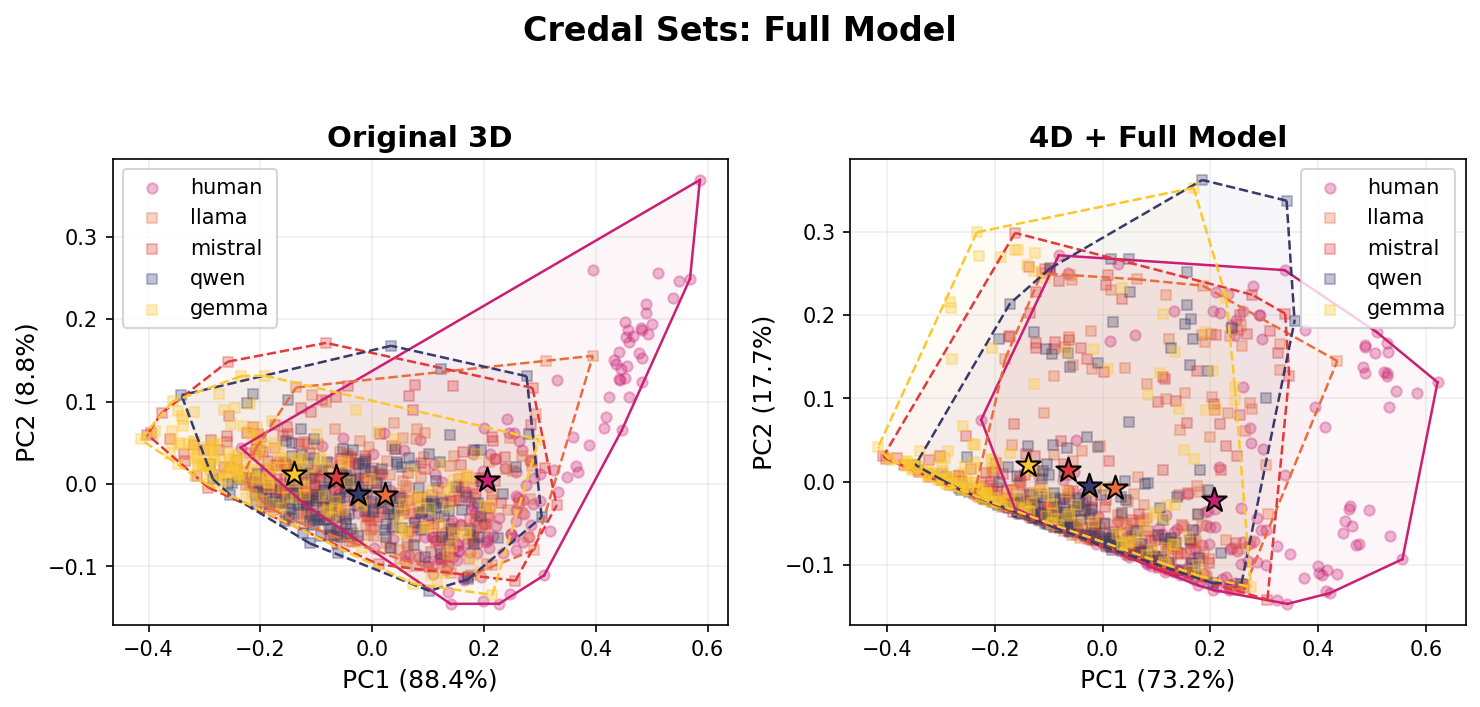

In [77]:
# Credal Sets: 3D vs 4D

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, data_dict, title in [
    (axes[0], {s: results_4d_full[s][:, :3] for s in SOURCES}, 'Original 3D'),
    (axes[1], results_4d_full, '4D + Full Model'),
]:
    all_data = np.vstack([data_dict[s] for s in SOURCES])
    pca_2d = PCA(n_components=2)
    all_pca = pca_2d.fit_transform(all_data)
    for i, source in enumerate(SOURCES):
        n = len(data_dict[source])
        pts = all_pca[i*n:(i+1)*n]
        marker = 'o' if source == 'human' else 's'
        ax.scatter(pts[:, 0], pts[:, 1], c=SOURCE_COLORS[source], alpha=0.3,
                  s=25, marker=marker, label=source)
        centroid = pts.mean(axis=0)
        ax.scatter(*centroid, c=SOURCE_COLORS[source], s=150, marker='*',
                  edgecolors='black', linewidth=1, zorder=5)
        try:
            hull = ConvexHull(pts)
            for simplex in hull.simplices:
                ls = '-' if source == 'human' else '--'
                ax.plot(pts[simplex, 0], pts[simplex, 1],
                        color=SOURCE_COLORS[source], linewidth=1.2, linestyle=ls)
            poly = Polygon(pts[hull.vertices], alpha=0.04, color=SOURCE_COLORS[source])
            ax.add_patch(poly)
        except Exception:
            pass
    ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})', fontsize=12)
    ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.2)
plt.suptitle('Credal Sets: Full Model',
             fontsize=16, fontweight='bold', y=1.04)
plt.savefig(FIG_DIR / 'credal_sets_disc_full_4d.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [78]:
# Overlap-Koeffizienten

print('Overlap Human and Model — Full Model')
print(f'{"Model":<10} {"3D":>8} {"4D":>8} {"Δ":>8}')
print('-' * 38)
overlap_rows = []
for source in SOURCES[1:]:
    h = results_4d_full['human']
    m = results_4d_full[source]
    ov_3d = overlap_coefficient(h[:, :3], m[:, :3])
    ov_4d = overlap_coefficient(h, m)
    print(f'{source:<10} {ov_3d:>8.3f} {ov_4d:>8.3f} {ov_4d-ov_3d:>+8.3f}')
    overlap_rows.append({'model': source, 'overlap_3d': ov_3d, 'overlap_4d': ov_4d, 'delta': ov_4d - ov_3d})
pd.DataFrame(overlap_rows).to_csv(TABLE_DIR / 'overlap_disc_full.csv', index=False)

Overlap Human and Model — Full Model
Model            3D       4D        Δ
--------------------------------------
llama         0.050    0.017   -0.034
mistral       0.045    0.022   -0.022
qwen          0.025    0.039   +0.014
gemma         0.022    0.022   +0.000


In [79]:
# Credal Sets: D_disc Full Model

def pairwise_jsd_full_profiles(texts_list, alpha_trigram=0.3):
    """Compute pairwise JSD of combined bigram+trigram profiles for a list of texts"""
    profiles = []

    # Compute bigram and trigram profiles for each text
    for t in texts_list:
        bi, tri, _, _, _ = compute_transition_profile_full(t, use_trigrams=True)
        if tri is not None:
            combined = np.concatenate([(1 - alpha_trigram) * bi, alpha_trigram * tri])
        else:
            combined = bi
        profiles.append(combined)

    # Compute pairwise JSD for all unique pairs of combined profiles
    pairs = list(combinations(range(len(texts_list)), 2))
    return np.array([jsd(profiles[i], profiles[j]) for i, j in pairs])

raw_dists_full = {}
t0 = time.time()

# Compute pairwise JSD profiles for all prompts and sources
for source in SOURCES:
    raw_dists_full[source] = [
        pairwise_jsd_full_profiles(texts[source][p]) for p in range(N_PROMPTS)
    ]
    print(f'  {source:8s}: done ({time.time()-t0:.0f}s)')

# Transform raw distances to simplex points
all_raw_f = np.concatenate([np.concatenate(raw_dists_full[s]) for s in SOURCES])
sorted_ref_f = np.sort(all_raw_f)

def rank_transform_f(values):
    """Rank-transform distances to [0, 1] based on reference distribution"""
    return np.searchsorted(sorted_ref_f, values, side='right') / len(sorted_ref_f)

def dist_to_simplex_f(distances):
    """Convert raw distances to a smoothed histogram (simplex point)"""
    ranked = rank_transform_f(distances)
    counts, _ = np.histogram(ranked, bins=BIN_EDGES)
    smoothed = counts + ALPHA_SMOOTH
    return smoothed / smoothed.sum()

# Convert all raw distances to simplex points
simplex_full = {
    s: np.array([dist_to_simplex_f(raw_dists_full[s][p]) for p in range(N_PROMPTS)])
    for s in SOURCES
}

  human   : done (61s)
  llama   : done (138s)
  mistral : done (220s)
  qwen    : done (303s)
  gemma   : done (387s)


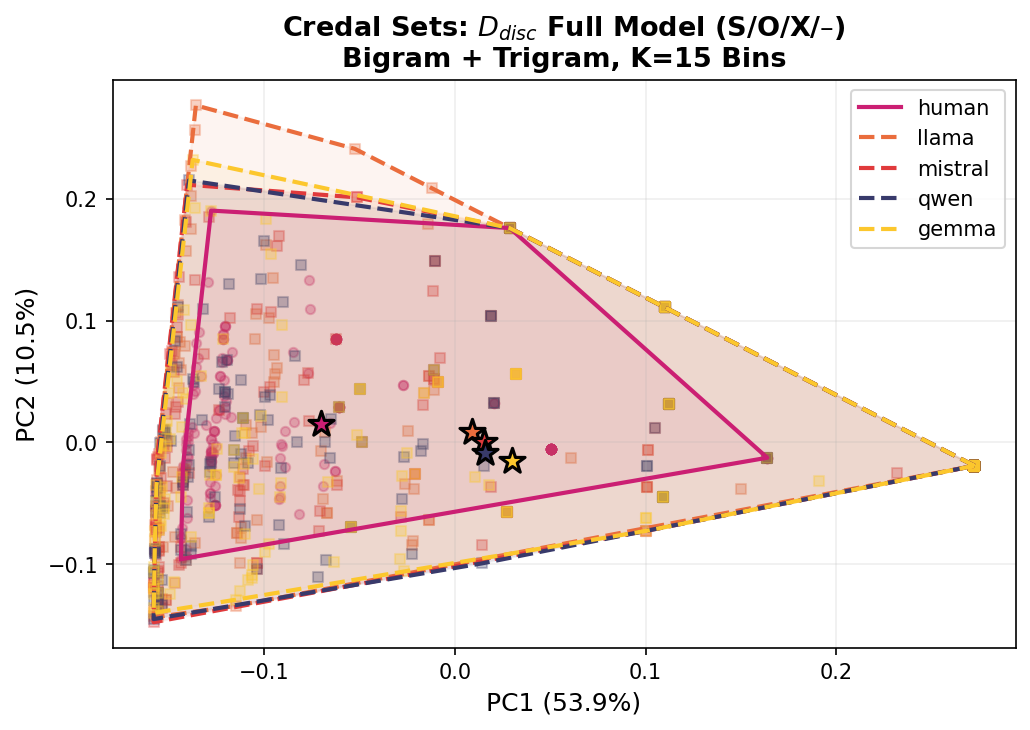

In [80]:
# Plot
all_sp_f = np.vstack([simplex_full[s] for s in SOURCES])
pca_disc_f = PCA(n_components=2).fit(all_sp_f)
d2d_f = {s: pca_disc_f.transform(simplex_full[s]) for s in SOURCES}

fig, ax = plt.subplots(figsize=(7, 5))
for source in SOURCES:
    pts = d2d_f[source]
    ls = '-' if source == 'human' else '--'
    marker = 'o' if source == 'human' else 's'
    ax.scatter(pts[:, 0], pts[:, 1], c=SOURCE_COLORS[source],
               alpha=0.3, s=20, marker=marker)
    centroid = pts.mean(axis=0)
    ax.scatter(*centroid, c=SOURCE_COLORS[source], s=160, marker='*',
               edgecolors='black', linewidth=1.5, zorder=6)
    try:
        hull = ConvexHull(pts)
        hull_idx = np.append(hull.vertices, hull.vertices[0])
        ax.fill(pts[hull.vertices, 0], pts[hull.vertices, 1],
                alpha=0.07, color=SOURCE_COLORS[source])
        ax.plot(pts[hull_idx, 0], pts[hull_idx, 1],
                color=SOURCE_COLORS[source], linewidth=2,
                linestyle=ls, label=source)
    except Exception:
        pass
ax.set_xlabel(f'PC1 ({pca_disc_f.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca_disc_f.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax.set_title('Credal Sets: $D_{disc}$ Full Model (S/O/X/–)\n'
             'Bigram + Trigram, K=15 Bins',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(FIG_DIR / 'credal_sets_disc_full.png', dpi=300, bbox_inches='tight')
plt.show()

# Control Analysis: Raw Values vs. Distances for full Model

- Human-vs-Model difference in $D_{\text{disc}}$ could be an artifact of **distance computation** (mean pairwise JSD between entity-grid profiles) rather than a difference in discourse structure
- JSD between distributions estimated from few counts is noisy
- Texts with fewer sentences/entities yield less stable profiles, which pushes pairwise JSD up systematically, independent of "true" structural diversity

Two checks:
1. **Raw, pooled transition profiles per source** (mean over all texts, no pairwise distance): shows whether the
   shape of the discourse structure actually differs between sources
2. **Confounding by text length / entity count**: tests whether $D_{\text{disc}}$ correlates with the number of
   sentences or usable entities

In [81]:
# Raw statistics: sentence count, entity count (total and used), transition profiles (bigram+trigram)
import pandas as pd
from scipy.stats import spearmanr
from sklearn.linear_model import LinearRegression


def analyze_texts_full(texts_list, use_trigrams=False):
    """Profiles + raw statistics (sentence/entity count) for a list of texts (Full model)"""
    # Initialize lists to store results
    profiles_bi, n_sents_l, n_ent_used_l, n_ent_total_l = [], [], [], []

    # Compute transition profiles and statistics for each text
    for t in texts_list:
        # Compute bigram and trigram profiles
        bi, _, grid, sents, entity_freq = compute_transition_profile_full(t, use_trigrams=use_trigrams)
        profiles_bi.append(bi)
        # Sentence count
        n_sents_l.append(len(sents))
        # Entity counts
        n_ent_total_l.append(len(entity_freq))
        # Count of entities used (frequency >= MIN_ENTITY_FREQ)
        n_ent_used_l.append(sum(1 for f in entity_freq.values() if f >= MIN_ENTITY_FREQ))
    return {
        'profiles_bi': np.array(profiles_bi),
        'n_sents': np.array(n_sents_l),
        'n_entities_total': np.array(n_ent_total_l),
        'n_entities_used': np.array(n_ent_used_l),
    }


raw_stats_full = {}
t0 = time.time()
for source in SOURCES:
    raw_stats_full[source] = [analyze_texts_full(texts[source][p]) for p in range(N_PROMPTS)]
    print(f'  {source:8s}: done ({time.time()-t0:.0f}s)')
print(f'\nRaw statistics computed in {time.time()-t0:.0f}s')

  human   : done (60s)
  llama   : done (142s)
  mistral : done (222s)
  qwen    : done (297s)
  gemma   : done (384s)

Raw statistics computed in 384s


## Raw, pooled transition profiles per source

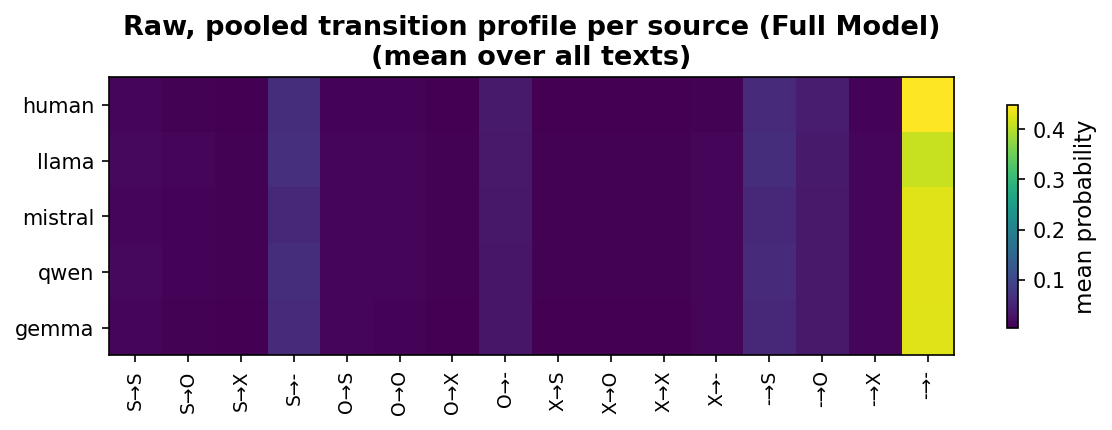

Source       H(mean profile)   D_disc (mean JSD)
------------------------------------------------
human                  2.169               0.093
llama                  2.414               0.068
mistral                2.323               0.068
qwen                   2.369               0.059
gemma                  2.239               0.055


In [82]:
# Pooled mean transition profile per source (across all prompts & texts)
mean_profile_full = {}
for source in SOURCES:
    all_profiles = np.vstack([raw_stats_full[source][p]['profiles_bi'] for p in range(N_PROMPTS)])
    mean_profile_full[source] = all_profiles.mean(axis=0)

# Heatmap: sources x 16 bigram transitions
fig, ax = plt.subplots(figsize=(8, 3))
mat = np.vstack([mean_profile_full[s] for s in SOURCES])
im = ax.imshow(mat, cmap='viridis', aspect='auto')
ax.set_yticks(range(len(SOURCES))); ax.set_yticklabels(SOURCES)
ax.set_xticks(range(N_BIGRAM))
ax.set_xticklabels([f'{a}\u2192{b}' for a, b in BIGRAM_TRANSITIONS], rotation=90, fontsize=9)
ax.set_title('Raw, pooled transition profile per source (Full Model)\n(mean over all texts)',
             fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.8, label='mean probability')
plt.tight_layout()
plt.savefig(FIG_DIR / 'raw_profile_heatmap_full.png', dpi=150, bbox_inches='tight')
plt.show()

# Entropy of the POOLED profile (= diversity of the "typical" structure, not a distance)
# vs. D_disc (mean pairwise JSD) -- shows whether both measures rank the sources the same way
print(f'{"Source":<10}{"H(mean profile)":>18}{"D_disc (mean JSD)":>20}')
print('-' * 48)
entropy_rows = []
for source in SOURCES:
    h = entropy(mean_profile_full[source] + 1e-10, base=2)
    print(f'{source:<10}{h:>18.3f}{disc_scores_full[source].mean():>20.3f}')
    entropy_rows.append({'source': source, 'H_mean_profile': h, 'D_disc_mean_jsd': disc_scores_full[source].mean()})
pd.DataFrame(entropy_rows).to_csv(TABLE_DIR / 'entropy_vs_ddisc_full.csv', index=False)

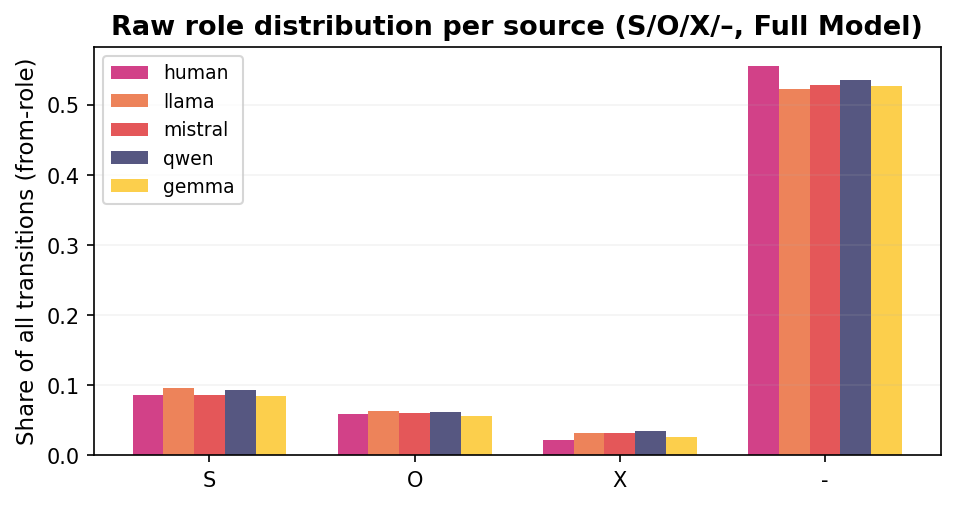

In [83]:
# Role occupancy (S/O/X/-) pooled per source (simplest "raw" summary)
role_occ_full = {}
for source in SOURCES:
    p = mean_profile_full[source].reshape(4, 4)  # rows = from-role, cols = to-role (order: ROLES)
    role_occ_full[source] = p.sum(axis=1)  # share of all transitions where an entity starts in this role

fig, ax = plt.subplots(figsize=(6.5, 3.5))
x = np.arange(4)
width = 0.15
for j, source in enumerate(SOURCES):
    ax.bar(x + j * width, role_occ_full[source], width, label=source, color=SOURCE_COLORS[source], alpha=0.85)
ax.set_xticks(x + 2 * width); ax.set_xticklabels(ROLES)
ax.set_ylabel('Share of all transitions (from-role)')
ax.set_title('Raw role distribution per source (S/O/X/\u2013, Full Model)', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.15, axis='y')
plt.tight_layout()
plt.savefig(FIG_DIR / 'raw_role_occupancy_full.png', dpi=150, bbox_inches='tight')
plt.show()

## Confounding by text length / entity count

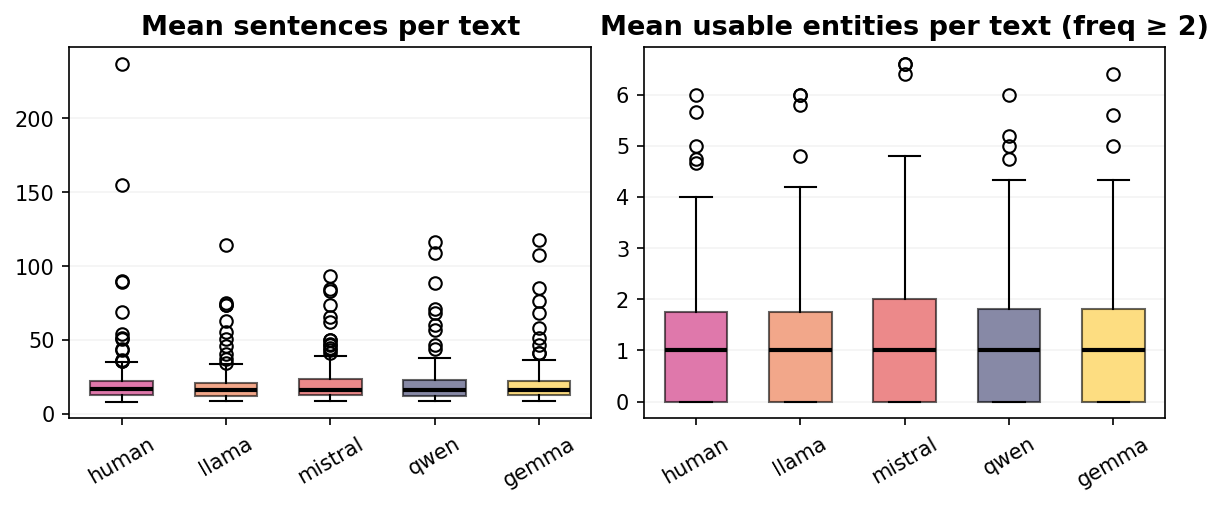

In [84]:
# Per-prompt averaged raw statistics (across the texts of a source)
mean_n_sents_full = {s: np.array([raw_stats_full[s][p]['n_sents'].mean() for p in range(N_PROMPTS)]) for s in SOURCES}
mean_n_ent_used_full = {s: np.array([raw_stats_full[s][p]['n_entities_used'].mean() for p in range(N_PROMPTS)]) for s in SOURCES}

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
for ax, data_dict, title in [
    (axes[0], mean_n_sents_full, 'Mean sentences per text'),
    (axes[1], mean_n_ent_used_full, f'Mean usable entities per text (freq \u2265 {MIN_ENTITY_FREQ})'),
]:
    data = [data_dict[s] for s in SOURCES]
    bp = ax.boxplot(data, labels=SOURCES, patch_artist=True, widths=0.6,
                     medianprops=dict(color='black', linewidth=2))
    for patch, s in zip(bp['boxes'], SOURCES):
        patch.set_facecolor(SOURCE_COLORS[s]); patch.set_alpha(0.6)
    ax.set_title(title, fontweight='bold'); ax.tick_params(axis='x', rotation=30)
    ax.grid(True, alpha=0.15, axis='y')
plt.tight_layout()
plt.savefig(FIG_DIR / 'confound_length_entities_full.png', dpi=150, bbox_inches='tight')
plt.show()

In [85]:
# Spearman correlation D_disc and confound variables within each source (over N_PROMPTS prompts)
# -> any correlation here can only come from noise/the distance computation

print(f'Spearman correlation D_disc <-> confound variables (per source, over {N_PROMPTS} prompts)')
print(f'{"Source":<10}{"rho(n_sents)":>15}{"p":>10}{"rho(n_ent_used)":>18}{"p":>10}')
print('-' * 65)
confound_rows = []
for source in SOURCES:
    r1, p1 = spearmanr(mean_n_sents_full[source], disc_scores_full[source])
    r2, p2 = spearmanr(mean_n_ent_used_full[source], disc_scores_full[source])
    print(f'{source:<10}{r1:>15.3f}{p1:>10.3f}{r2:>18.3f}{p2:>10.3f}')
    confound_rows.append({
        'source': source, 'rho_n_sents': r1, 'p_n_sents': p1,
        'rho_n_ent_used': r2, 'p_n_ent_used': p2,
    })
pd.DataFrame(confound_rows).to_csv(TABLE_DIR / 'confound_spearman_full.csv', index=False)

Spearman correlation D_disc <-> confound variables (per source, over 179 prompts)
Source       rho(n_sents)         p   rho(n_ent_used)         p
-----------------------------------------------------------------
human               0.126     0.094             0.368     0.000
llama               0.199     0.007             0.483     0.000
mistral             0.327     0.000             0.463     0.000
qwen                0.228     0.002             0.509     0.000
gemma               0.268     0.000             0.504     0.000


In [86]:
# Does the Human-vs-Model gap in D_disc survive after controlling for sentence/entity count?
rows = []
for source in SOURCES:
    for p in range(N_PROMPTS):
        rows.append({
            'source': source,
            'is_human': int(source == 'human'),
            'D_disc': disc_scores_full[source][p],
            'n_sents': mean_n_sents_full[source][p],
            'n_ent_used': mean_n_ent_used_full[source][p],
        })
df_confound_full = pd.DataFrame(rows)

# Linear regression: D_disc ~ is_human (+ confounds)
y = df_confound_full['D_disc'].values
X_raw = df_confound_full[['is_human']].values
X_ctrl = df_confound_full[['is_human', 'n_sents', 'n_ent_used']].values

m_raw = LinearRegression().fit(X_raw, y)
m_ctrl = LinearRegression().fit(X_ctrl, y)

print('Without control (matches the boxplot and Cohen\'s d above):')
print(f"  is_human coefficient: {m_raw.coef_[0]:+.4f}   (R\u00b2={m_raw.score(X_raw, y):.3f})")
print()
print('With control for sentence/entity count:')
print(f"  is_human coefficient:   {m_ctrl.coef_[0]:+.4f}   (R\u00b2={m_ctrl.score(X_ctrl, y):.3f})")
print(f"  n_sents coefficient:    {m_ctrl.coef_[1]:+.4f}")
print(f"  n_ent_used coefficient: {m_ctrl.coef_[2]:+.4f}")
print()
print(f"  Share of the is_human effect remaining after control: "
      f"{m_ctrl.coef_[0] / m_raw.coef_[0] * 100:.0f}%")

df_confound_full.to_csv(TABLE_DIR / 'confound_per_prompt_full.csv', index=False)
pd.DataFrame([
    {'model': 'raw', 'is_human_coef': m_raw.coef_[0], 'n_sents_coef': None,
     'n_ent_used_coef': None, 'r2': m_raw.score(X_raw, y)},
    {'model': 'controlled', 'is_human_coef': m_ctrl.coef_[0], 'n_sents_coef': m_ctrl.coef_[1],
     'n_ent_used_coef': m_ctrl.coef_[2], 'r2': m_ctrl.score(X_ctrl, y)},
]).to_csv(TABLE_DIR / 'confound_regression_full.csv', index=False)

Without control (matches the boxplot and Cohen's d above):
  is_human coefficient: +0.0302   (R²=0.014)

With control for sentence/entity count:
  is_human coefficient:   +0.0306   (R²=0.019)
  n_sents coefficient:    -0.0002
  n_ent_used coefficient: -0.0051

  Share of the is_human effect remaining after control: 101%


# Entity-Frequency Filter (MIN_ENTITY_FREQ)

- Entity-frequency filter (`MIN_ENTITY_FREQ = 2`) drops entities that appear in only one sentence before the bigram/trigram counts are built 
- Motivated by Barzilay & Lapata's "salience" concept: single mentions mostly just add `-` transitions
- But the profile is already salience-weighted via `log(1 + freq)`, which softly down-weights rare entities  
-> Hard cutoff may be partly redundant with the weighting
- Plausible driver of the sparsity problem (median: 1 usable entity per text at `MIN_ENTITY_FREQ = 2`).

Checking:
1. Does usable-entity count per text increase as the filter is loosened (as expected)?
2. Does the sparsity artifact (correlation between $D_{\text{disc}}$ and entity count) shrink?
3. Does discrimination between Human and Model survive across thresholds?

In [87]:
# Cache entity grids for all texts and prompts, so that we can reuse them later without re-parsing

t0 = time.time()
cached_grids = {}
for source in SOURCES:
    cached_grids[source] = [
        [build_entity_grid_full(t) for t in texts[source][p]] for p in range(N_PROMPTS)
    ]
    print(f'  {source:8s}: done ({time.time()-t0:.0f}s)')
print(f'\nEntity grids cached in {time.time()-t0:.0f}s')

  human   : done (61s)
  llama   : done (146s)
  mistral : done (243s)
  qwen    : done (326s)
  gemma   : done (410s)

Entity grids cached in 410s


In [88]:
# Filtering for different MIN_ENTITY_FREQ thresholds

def profile_from_grid(grid, entity_freq, min_freq, use_trigrams=True):
    """Bigram/trigram profile from a pre-built entity grid, for a given MIN_ENTITY_FREQ threshold."""
    if not grid:
        return (np.ones(N_BIGRAM) / N_BIGRAM,
                np.ones(N_TRIGRAM) / N_TRIGRAM if use_trigrams else None, 0)
    
    bigram_counts, trigram_counts = Counter(), Counter()
    n_used = 0

    # Count weighted bigram/trigram transitions for entities that meet the frequency threshold
    for entity, roles_seq in grid.items():
        if entity_freq[entity] < min_freq:
            continue
        n_used += 1

        # Weight transitions by the log of the entity's frequency to emphasize more salient entities
        weight = np.log(1 + entity_freq[entity])

        for k in range(len(roles_seq) - 1):
            bigram_counts[(roles_seq[k], roles_seq[k+1])] += weight

        # Count trigrams if enabled and if the entity has enough roles
        if use_trigrams and len(roles_seq) >= 3:
            for k in range(len(roles_seq) - 2):
                trigram_counts[(roles_seq[k], roles_seq[k+1], roles_seq[k+2])] += weight
    
    bigram_total = sum(bigram_counts.values()) or 1
    bigram_profile = np.array([bigram_counts[t] / bigram_total for t in BIGRAM_TRANSITIONS])
    trigram_profile = None
    if use_trigrams:
        trigram_total = sum(trigram_counts.values()) or 1
        trigram_profile = np.array([trigram_counts[t] / trigram_total for t in TRIGRAM_TRANSITIONS])
    return bigram_profile, trigram_profile, n_used


def discourse_diversity_from_cache(prompt_grids, min_freq, use_trigrams=True, alpha_trigram=0.3):
    """D_disc for one prompt's cached grids, at a given MIN_ENTITY_FREQ threshold."""
    profiles_bi, profiles_tri, n_used_list = [], [], []

    # Compute bigram/trigram profiles for each text in the prompt
    for grid, sents, entity_freq in prompt_grids:
        bi, tri, n_used = profile_from_grid(grid, entity_freq, min_freq, use_trigrams=use_trigrams)
        profiles_bi.append(bi)
        if tri is not None:
            profiles_tri.append(tri)
        n_used_list.append(n_used)
    
    # Compute pairwise JSD for bigram profiles
    profiles_bi = np.array(profiles_bi)
    pairs = list(combinations(range(len(prompt_grids)), 2))
    jsd_bi = np.mean([jsd(profiles_bi[i], profiles_bi[j]) for i, j in pairs])
    if use_trigrams and profiles_tri:
        profiles_tri = np.array(profiles_tri)
        jsd_tri = np.mean([jsd(profiles_tri[i], profiles_tri[j]) for i, j in pairs])
        d = (1 - alpha_trigram) * jsd_bi + alpha_trigram * jsd_tri
    else:
        d = jsd_bi
    return d, np.mean(n_used_list)


MIN_FREQS = [1, 2, 3]
disc_scores_mf = {mf: {} for mf in MIN_FREQS}
mean_n_used_mf = {mf: {} for mf in MIN_FREQS}

for mf in MIN_FREQS:
    for source in SOURCES:
        d_scores, n_used = [], []
        for p in range(N_PROMPTS):
            d, nu = discourse_diversity_from_cache(cached_grids[source][p], mf, use_trigrams=True, alpha_trigram=0.3)
            d_scores.append(d)
            n_used.append(nu)
        disc_scores_mf[mf][source] = np.array(d_scores)
        mean_n_used_mf[mf][source] = np.array(n_used)
    print(f'MIN_ENTITY_FREQ={mf}: done')

MIN_ENTITY_FREQ=1: done
MIN_ENTITY_FREQ=2: done
MIN_ENTITY_FREQ=3: done


## Does loosening the filter actually add usable entities?

In [89]:
print(f'{"MIN_ENTITY_FREQ":<18}', end='')
for s in SOURCES: print(f'{s:>10}', end='')
print()
print('-' * (18 + 10 * len(SOURCES)))
usable_entities_rows = []
for mf in MIN_FREQS:
    print(f'{mf:<18}', end='')
    row = {'min_entity_freq': mf}
    for s in SOURCES:
        val = np.median(mean_n_used_mf[mf][s])
        print(f'{val:>10.2f}', end='')
        row[s] = val
    print()
    usable_entities_rows.append(row)
print('\n(median usable entities per text, i.e. entities with freq >= MIN_ENTITY_FREQ)')

pd.DataFrame(usable_entities_rows).to_csv(TABLE_DIR / 'min_entity_freq_usable_entities.csv', index=False)

MIN_ENTITY_FREQ        human     llama   mistral      qwen     gemma
--------------------------------------------------------------------
1                       3.33      3.00      3.00      2.80      3.00
2                       1.00      1.00      1.00      1.00      1.00
3                       0.33      0.20      0.20      0.00      0.00

(median usable entities per text, i.e. entities with freq >= MIN_ENTITY_FREQ)


## Does the sparsity artifact shrink

In [90]:
print('Spearman rho(D_disc, n_entities_used) within source, by MIN_ENTITY_FREQ')
min_entity_freq_spearman_rows = []
for mf in MIN_FREQS:
    print(f'MIN_ENTITY_FREQ = {mf}')
    for source in SOURCES:
        r, p_ = spearmanr(mean_n_used_mf[mf][source], disc_scores_mf[mf][source])
        sig = '*' if p_ < 0.05 else ' '
        print(f'  {source:<10} rho={r:+.3f}  p={p_:.3f} {sig}')
        min_entity_freq_spearman_rows.append({'min_entity_freq': mf, 'source': source, 'rho': r, 'p': p_})
    print()

pd.DataFrame(min_entity_freq_spearman_rows).to_csv(TABLE_DIR / 'min_entity_freq_spearman.csv', index=False)

Spearman rho(D_disc, n_entities_used) within source, by MIN_ENTITY_FREQ
MIN_ENTITY_FREQ = 1
  human      rho=-0.255  p=0.001 *
  llama      rho=-0.182  p=0.015 *
  mistral    rho=-0.106  p=0.157  
  qwen       rho=-0.125  p=0.095  
  gemma      rho=+0.086  p=0.251  

MIN_ENTITY_FREQ = 2
  human      rho=+0.368  p=0.000 *
  llama      rho=+0.483  p=0.000 *
  mistral    rho=+0.463  p=0.000 *
  qwen       rho=+0.509  p=0.000 *
  gemma      rho=+0.504  p=0.000 *

MIN_ENTITY_FREQ = 3
  human      rho=+0.672  p=0.000 *
  llama      rho=+0.731  p=0.000 *
  mistral    rho=+0.714  p=0.000 *
  qwen       rho=+0.742  p=0.000 *
  gemma      rho=+0.796  p=0.000 *



##  Does Human-vs-Model discrimination survive?

In [91]:
def cohens_d(a, b):
    na, nb = len(a), len(b)
    pooled_std = np.sqrt(((na - 1) * a.std()**2 + (nb - 1) * b.std()**2) / (na + nb - 2))
    return (a.mean() - b.mean()) / pooled_std if pooled_std > 0 else 0


print(f'{"MIN_ENTITY_FREQ":<18}{"is_human coef":>15}{"R2":>8}{"Cohen d (H vs models)":>24}')
print('-' * 65)
ablation_rows = []
for mf in MIN_FREQS:
    rows = []
    for source in SOURCES:
        for p in range(N_PROMPTS):
            rows.append({'is_human': int(source == 'human'), 'D_disc': disc_scores_mf[mf][source][p]})
    df_mf = pd.DataFrame(rows)
    X = df_mf[['is_human']].values
    y = df_mf['D_disc'].values
    m = LinearRegression().fit(X, y)

    h = disc_scores_mf[mf]['human']
    all_models = np.concatenate([disc_scores_mf[mf][s] for s in SOURCES if s != 'human'])
    d = cohens_d(h, all_models)

    print(f'{mf:<18}{m.coef_[0]:>+15.4f}{m.score(X, y):>8.3f}{d:>24.3f}')
    ablation_rows.append({'min_entity_freq': mf, 'is_human_coef': m.coef_[0], 'r2': m.score(X, y), 'cohens_d': d})

pd.DataFrame(ablation_rows).to_csv(TABLE_DIR / 'min_entity_freq_ablation.csv', index=False)

MIN_ENTITY_FREQ     is_human coef      R2   Cohen d (H vs models)
-----------------------------------------------------------------
1                         +0.0167   0.008                   0.226
2                         +0.0302   0.014                   0.294
3                         +0.0322   0.014                   0.301


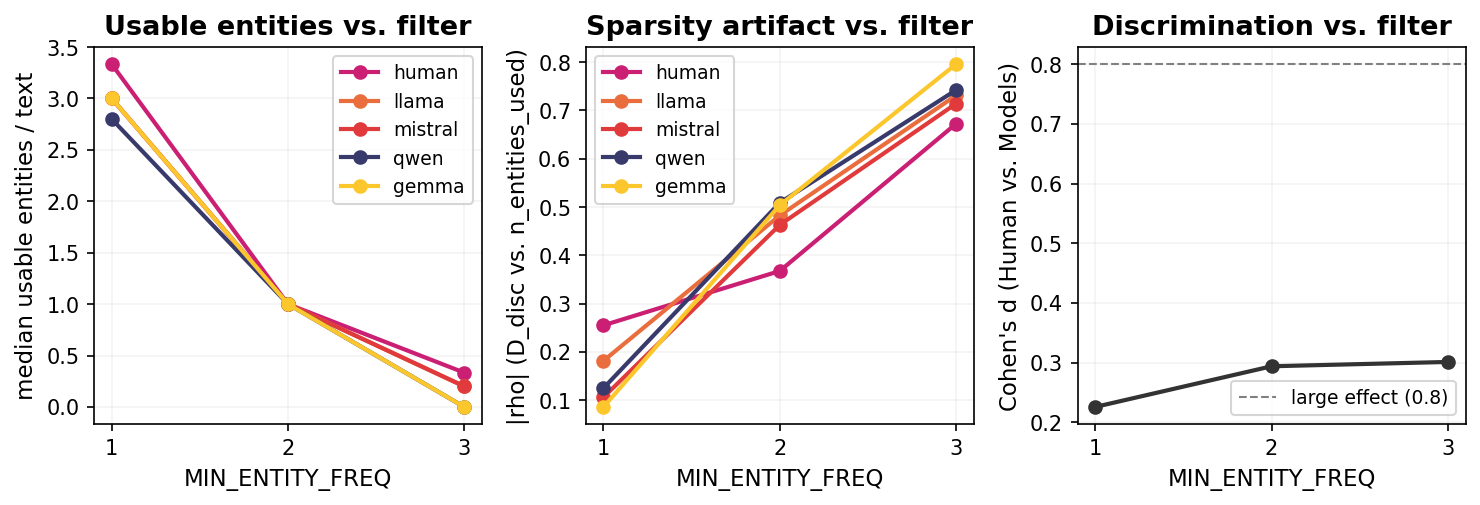

In [92]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))

# Panel 1: median usable entities by threshold
ax = axes[0]
for s in SOURCES:
    ax.plot(MIN_FREQS, [np.median(mean_n_used_mf[mf][s]) for mf in MIN_FREQS],
            'o-', color=SOURCE_COLORS[s], label=s, linewidth=2)
ax.set_xlabel('MIN_ENTITY_FREQ'); ax.set_ylabel('median usable entities / text')
ax.set_title('Usable entities vs. filter', fontweight='bold')
ax.set_xticks(MIN_FREQS)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.15)

# Panel 2: sparsity correlation magnitude by threshold
ax = axes[1]
for s in SOURCES:
    rhos = [abs(spearmanr(mean_n_used_mf[mf][s], disc_scores_mf[mf][s])[0]) for mf in MIN_FREQS]
    ax.plot(MIN_FREQS, rhos, 'o-', color=SOURCE_COLORS[s], label=s, linewidth=2)
ax.set_xlabel('MIN_ENTITY_FREQ'); ax.set_ylabel('|rho| (D_disc vs. n_entities_used)')
ax.set_title('Sparsity artifact vs. filter', fontweight='bold')
ax.set_xticks(MIN_FREQS)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.15)

# Panel 3: discrimination (Cohen's d) by threshold
ax = axes[2]
ds = []
for mf in MIN_FREQS:
    h = disc_scores_mf[mf]['human']
    all_models = np.concatenate([disc_scores_mf[mf][s] for s in SOURCES if s != 'human'])
    ds.append(cohens_d(h, all_models))
ax.plot(MIN_FREQS, ds, 'o-', color='#333333', linewidth=2)
ax.axhline(0.8, color='gray', linestyle='--', linewidth=1, label='large effect (0.8)')
ax.set_xlabel('MIN_ENTITY_FREQ'); ax.set_ylabel("Cohen's d (Human vs. Models)")
ax.set_title('Discrimination vs. filter', fontweight='bold')
ax.set_xticks(MIN_FREQS)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.15)

plt.tight_layout()
plt.savefig(FIG_DIR / 'ablation_min_entity_freq.png', dpi=150, bbox_inches='tight')
plt.show()